# Distance / Volume Analysis

Edge-level analysis notebook for validation subjects and validation-set aggregates.
It reuses `data.data_viz` helpers so distance matrices, partition handling, and upper-triangle extraction stay aligned with `data_overview_matrices.ipynb`.

The helper tables also expose `mean_volume` and `sum_volume` per edge for follow-up volume analyses.

In [55]:
import sys
from pathlib import Path
import importlib
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
sys.path.insert(0, str(REPO_ROOT))

import data.hcp_dataset as hcp_dataset
import data.data_viz as data_viz
importlib.reload(hcp_dataset)
importlib.reload(data_viz)

from data.hcp_dataset import HCP_Base
from data.data_viz import (
    get_edge_feature_table,
    plot_connectivity_vs_distance,
    compute_edgewise_distance_regression,
    plot_edgewise_regression_summary,
    plot_single_edge_distance_scatter,
)

In [56]:
import importlib
import data.data_viz as data_viz
importlib.reload(data_viz)
from data.data_viz import *
from data.data_viz import (
    get_edge_feature_table,
    get_partition_edge_feature_table,
    plot_connectivity_vs_distance,
    compute_edgewise_distance_regression,
    plot_edgewise_regression_summary,
    plot_single_edge_distance_scatter,
)


In [57]:
PARCELLATION = '4S456Parcels'
HEMI = 'both'
SHUFFLE_SEED = 0
DATA_LOAD_MODE = 'precomputed'

base = HCP_Base(
    parcellation=PARCELLATION,
    shuffle_seed=SHUFFLE_SEED,
    hemi=HEMI,
    source='SC',
    target='FC',
    data_load_mode=DATA_LOAD_MODE,
    write_manual_cache=False,
    expose_node_features=False,
)

VAL_INDICES = np.asarray(base.trainvaltest_partition_indices['val'])
VAL_SUBJECT_IDS = base.metadata_df.iloc[VAL_INDICES]['subject'].astype(str).tolist()

print(f'Parcellation: {base.parcellation}')
print(f'Hemisphere: {base.hemi}')
print(f'Validation subjects: {len(VAL_SUBJECT_IDS)}')
print(f'First validation subject: {VAL_SUBJECT_IDS[0]}')

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Parcellation: 4S456Parcels
Hemisphere: both
Validation subjects: 79
First validation subject: 100408


## Single validation subject

Raw edge-level scatter plots for one validation subject.

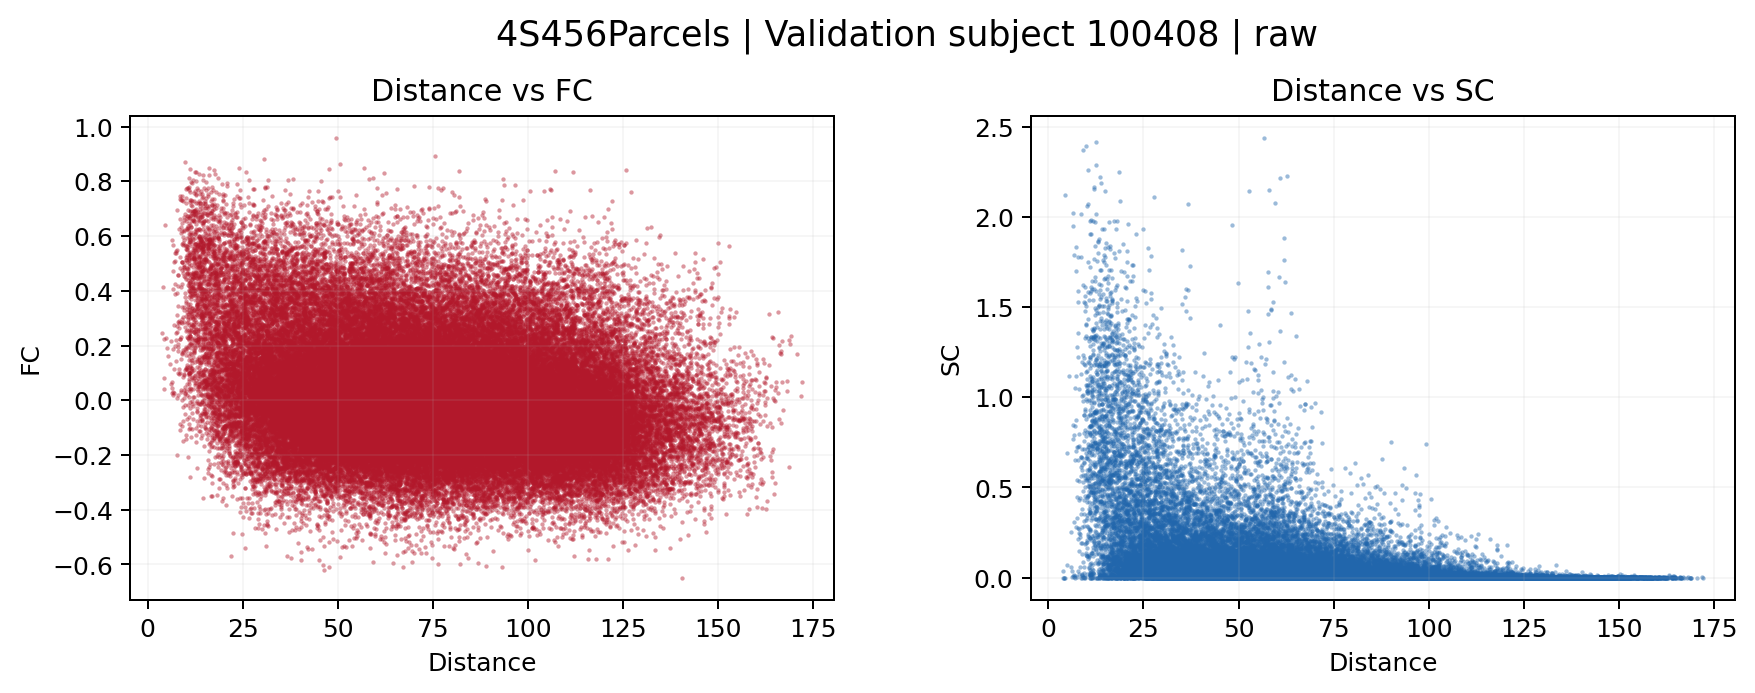

,distance,mean_volume,sum_volume,SC,FC
count,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000
mean,75.0424,2464.5481,4929.0962,0.0456,0.0109
std,29.0788,1853.4249,3706.8499,0.1549,0.1901
min,3.8498,31.2500,62.5000,0.0000,-0.6477
25%,53.9771,1613.2812,3226.5625,0.0000,-0.1093
50%,73.7733,2113.2812,4226.5625,0.0025,-0.0109
75%,95.6110,2710.9375,5421.8750,0.0169,0.1026
max,171.9806,29410.1562,58820.3125,2.4404,0.9596


In [36]:
SUBJECT_ID = VAL_SUBJECT_IDS[0]

subject_edge_df = get_edge_feature_table(
    base,
    partition='val',
    subject_id=SUBJECT_ID,
)

fig, axes = plot_connectivity_vs_distance(
    subject_edge_df,
    suptitle=f"{base.parcellation} | Validation subject {SUBJECT_ID} | raw",
    alpha=0.45,
    s=3,
)

subject_edge_df[['distance', 'mean_volume', 'sum_volume', 'SC', 'FC']].describe().round(4)

## Single validation subject demeaned

Subject-minus-train-mean residuals for the same edge set.

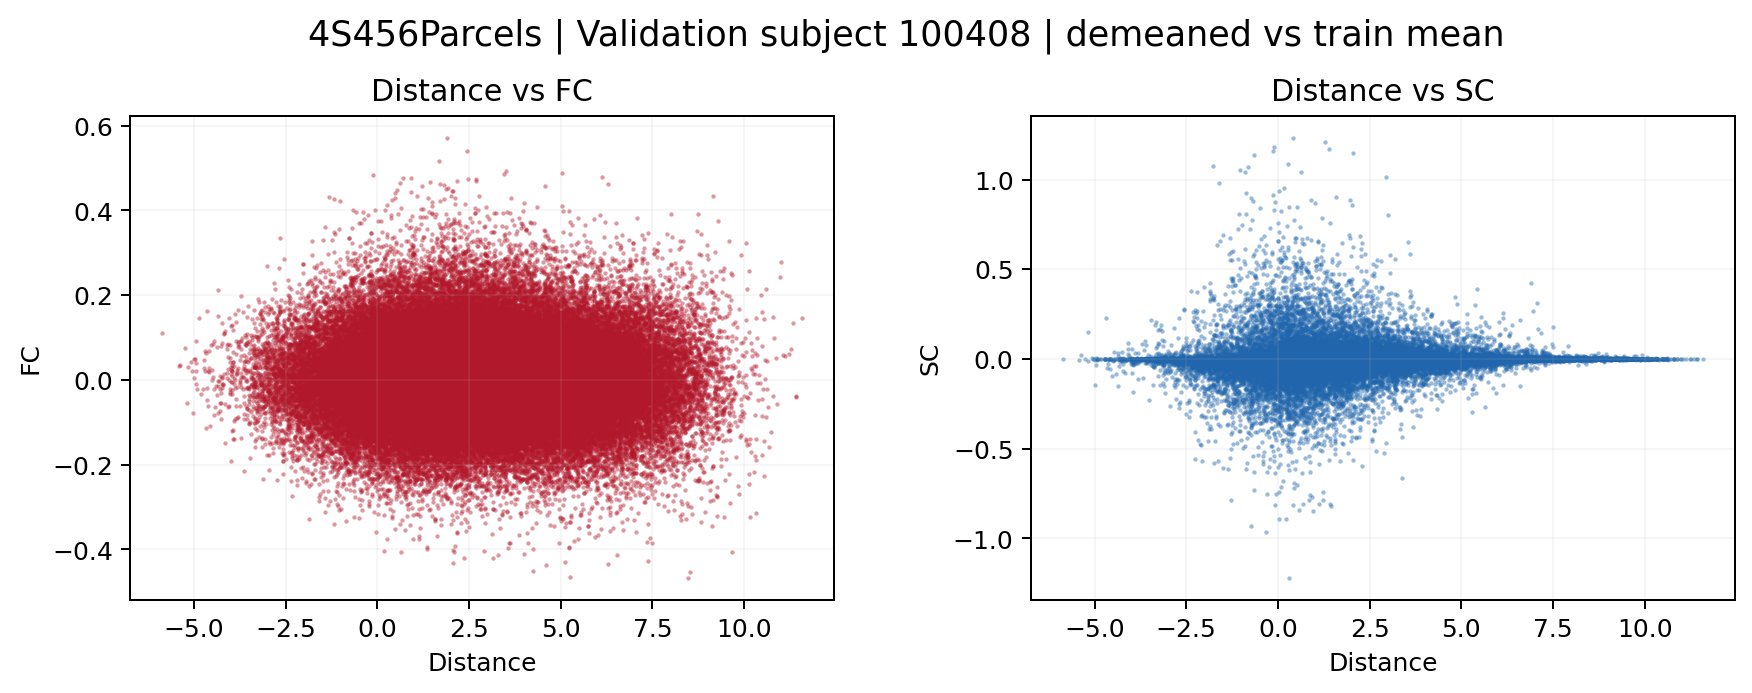

,distance,mean_volume,sum_volume,SC,FC
count,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000
mean,2.7933,215.6716,431.3432,-0.0026,0.0025
std,2.4467,335.1740,670.3480,0.0610,0.0972
min,-5.8592,-624.7263,-1249.4526,-1.2180,-0.4663
25%,1.0555,43.6491,87.2982,-0.0040,-0.0605
50%,2.6931,160.0552,320.1103,-0.0005,-0.0001
75%,4.4790,301.1415,602.2830,0.0005,0.0626
max,11.5781,4851.0840,9702.1680,1.2341,0.5717


In [37]:
subject_edge_dm_df = get_edge_feature_table(
    base,
    partition='val',
    subject_id=SUBJECT_ID,
    demean_partition='train',
    demean_aggregation='mean',
    demean_apply_fisher_z=False,
)

fig, axes = plot_connectivity_vs_distance(
    subject_edge_dm_df,
    suptitle=f"{base.parcellation} | Validation subject {SUBJECT_ID} | demeaned vs train mean",
    alpha=0.45,
    s=3,
)

subject_edge_dm_df[['distance', 'mean_volume', 'sum_volume', 'SC', 'FC']].describe().round(4)

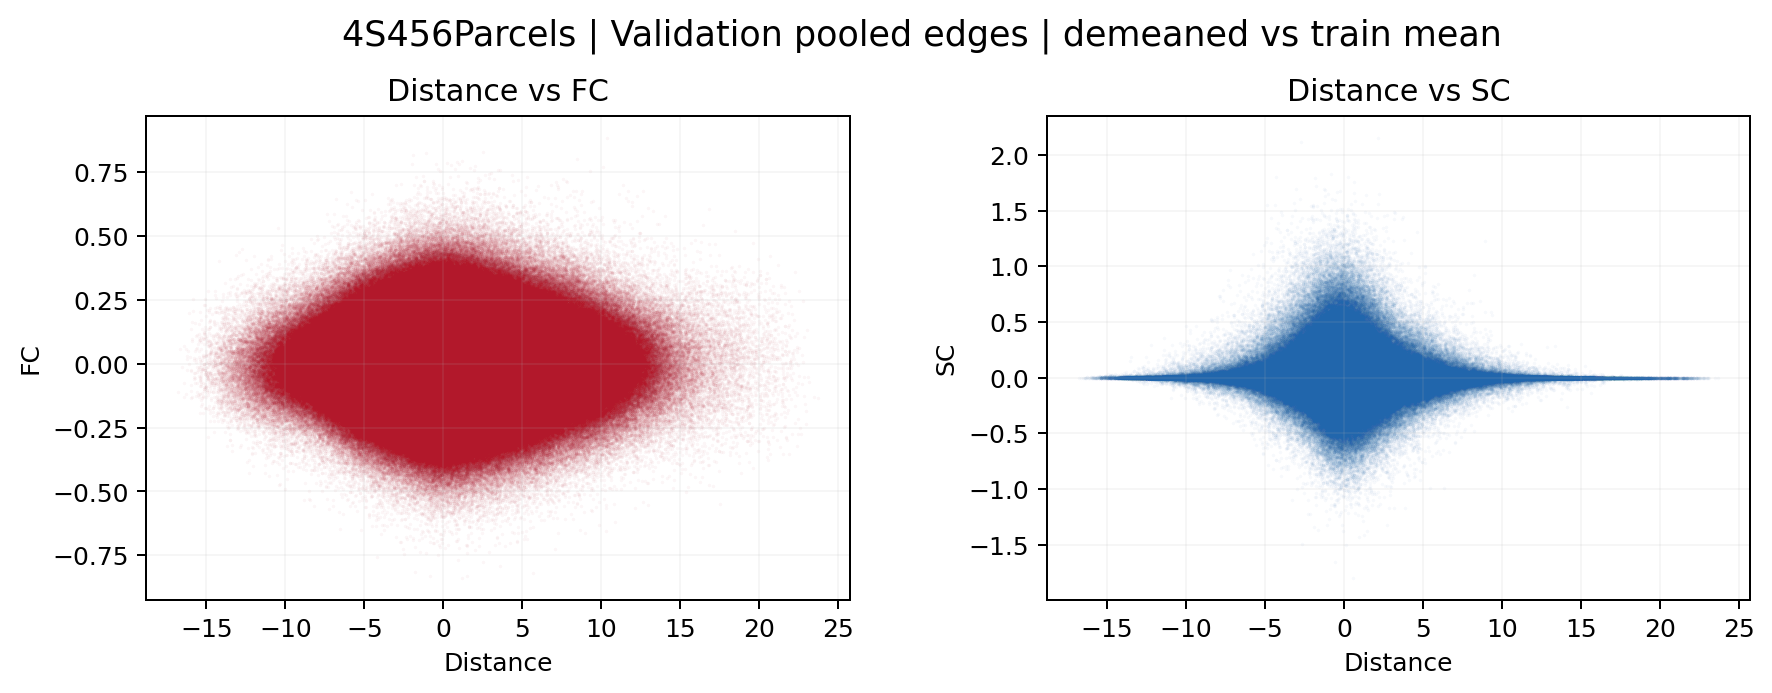

,distance,mean_volume,sum_volume,SC,FC
count,8.195460e+06,8.195460e+06,8.195460e+06,8.195460e+06,8.195460e+06
mean,4.077000e-01,3.501940e+01,7.003880e+01,-6.000000e-04,-3.000000e-04
std,3.429000e+00,3.520329e+02,7.040659e+02,6.560000e-02,1.128000e-01
min,-1.678750e+01,-6.698721e+03,-1.339744e+04,-1.795600e+00,-8.368000e-01
25%,-1.758800e+00,-1.629661e+02,-3.259322e+02,-3.700000e-03,-6.930000e-02
50%,2.423000e-01,5.931400e+00,1.186290e+01,-4.000000e-04,-7.000000e-04
75%,2.391500e+00,1.992662e+02,3.985323e+02,7.000000e-04,6.830000e-02
max,2.371210e+01,6.784678e+03,1.356936e+04,2.155400e+00,8.841000e-01


In [38]:
val_edge_dm_df = get_partition_edge_feature_table(
    base,
    partition='val',
    demean_partition='train',
    demean_aggregation='mean',
    demean_apply_fisher_z=False,
)

fig, axes = plot_connectivity_vs_distance(
    val_edge_dm_df,
    suptitle=f"{base.parcellation} | Validation pooled edges | demeaned vs train mean",
    alpha=0.035,
    s=2,
)

val_edge_dm_df[['distance', 'mean_volume', 'sum_volume', 'SC', 'FC']].describe().round(4)


## Edgewise Regression Analysis

Use the training partition for edge discovery, then inspect whether the strongest distance relationships still look similar in validation and test.
For volume and SC, treat significance as a nested-model block test rather than a single-coefficient test.


In [58]:
import importlib
import data.data_viz as data_viz
importlib.reload(data_viz)

from data.data_viz import (
    compute_edgewise_distance_regression,
    compute_edgewise_multifeature_regression,
    compare_edgewise_models,
    plot_edgewise_regression_summary,
    plot_multifeature_regression_summary,
    plot_single_edge_distance_scatter_across_partitions,
)


## Distance Discovery On Train

Fit one distance-only regression per edge on the training subjects and identify FDR-significant positive and negative edges.


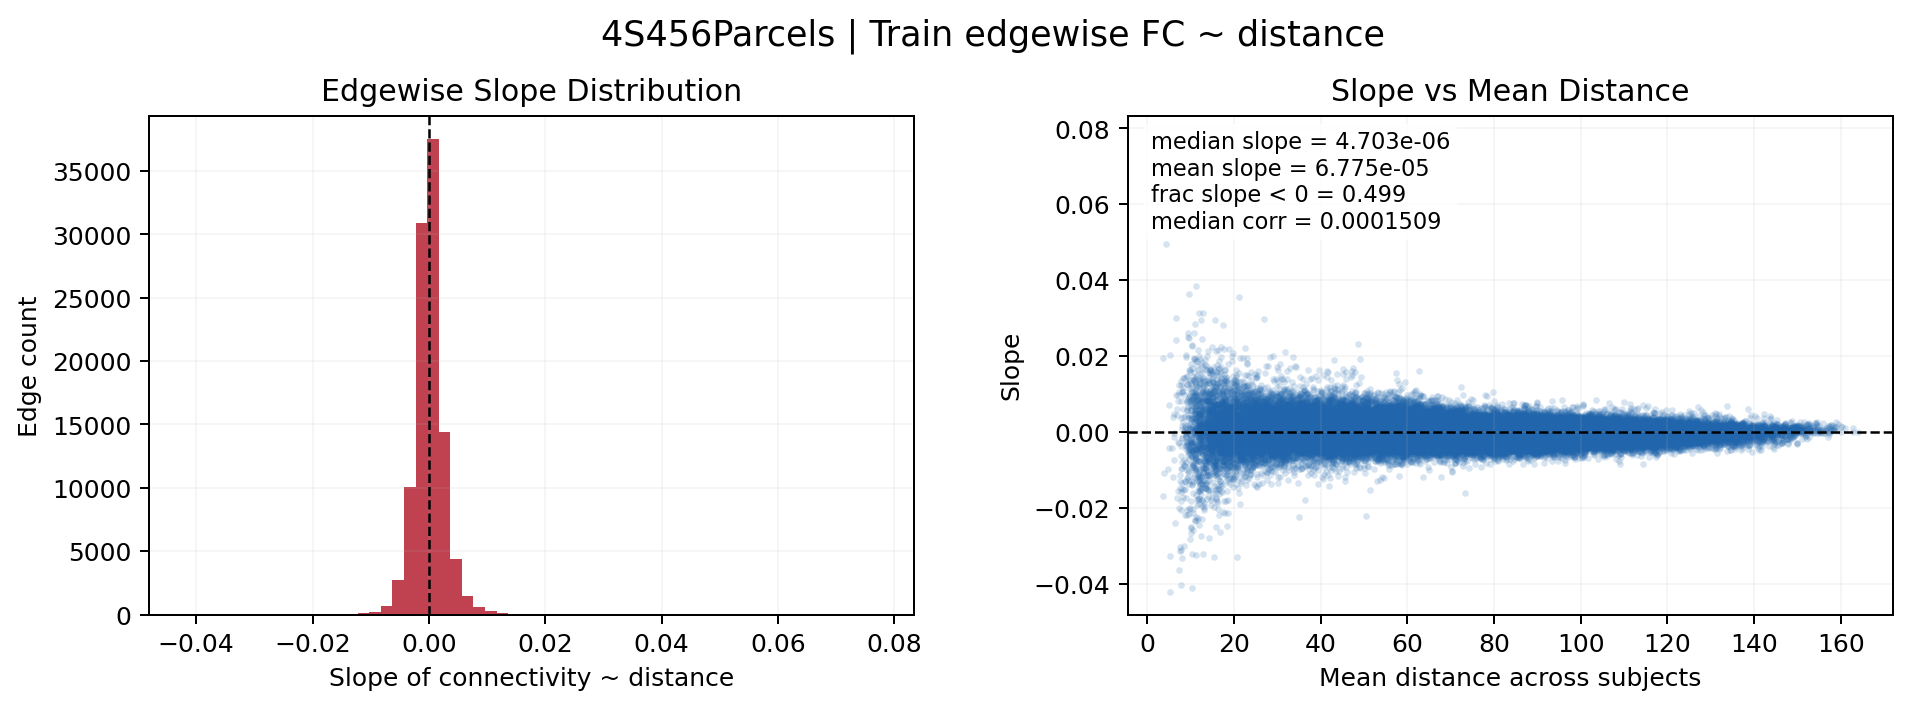

,slope,corr,r2,t_stat,p_value,q_value,distance_mean,distance_std,fc_mean,fc_std
count,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000
mean,0.0001,-0.0006,0.0041,-0.0151,0.3496,0.5172,72.2491,3.3248,0.0084,0.1068
std,0.0027,0.0642,0.0061,1.6872,0.3107,0.3161,27.6201,1.0462,0.1570,0.0287
min,-0.0421,-0.2859,0.0000,-7.7867,0.0000,0.0000,3.5509,0.1854,-0.5244,0.0459
25%,-0.0013,-0.0427,0.0004,-1.1150,0.0575,0.2298,52.2611,2.6054,-0.0847,0.0874
50%,0.0000,0.0002,0.0018,0.0039,0.2690,0.5379,71.3749,3.2742,-0.0115,0.1036
75%,0.0013,0.0420,0.0053,1.0976,0.6044,0.8058,91.8979,4.0292,0.0677,0.1242
max,0.0774,0.2816,0.0818,7.6572,1.0000,1.0000,163.9672,7.1260,0.8744,0.2971


In [59]:
train_fc_dist_reg_df = compute_edgewise_distance_regression(
    base,
    partition='train',
    y_key='FC',
    fdr_alpha=0.05,
)

fig, axes = plot_edgewise_regression_summary(
    train_fc_dist_reg_df,
    suptitle=f"{base.parcellation} | Train edgewise FC ~ distance",
)

train_fc_dist_reg_df[[
    'slope', 'corr', 'r2', 't_stat', 'p_value', 'q_value',
    'distance_mean', 'distance_std', 'fc_mean', 'fc_std'
]].describe().round(4)


In [60]:
distance_display_cols = [
    'edge_idx', 'slope', 'corr', 'r2', 'p_value', 'q_value', 'significant_fdr', 'distance_mean',
    'label_i', 'label_j',
    'hemisphere_i', 'hemisphere_j',
    'network_label_i', 'network_label_j',
    'network_label_17network_i', 'network_label_17network_j',
    'same_hemisphere', 'same_network', 'same_network_17',
]

train_distance_sig_df = train_fc_dist_reg_df[train_fc_dist_reg_df['significant_fdr']].copy()

print(f"Distance FDR-significant edges on train: {len(train_distance_sig_df)}")
display(train_distance_sig_df.sort_values('q_value')[distance_display_cols].head(25))

train_distance_top_negative = train_distance_sig_df.sort_values('slope', ascending=True)[distance_display_cols].head(10)
train_distance_top_positive = train_distance_sig_df.sort_values('slope', ascending=False)[distance_display_cols].head(10)

print('Most negative distance slopes (train, FDR-significant)')
display(train_distance_top_negative)
print('Most positive distance slopes (train, FDR-significant)')
display(train_distance_top_positive)


Distance FDR-significant edges on train: 9621


,edge_idx,slope,corr,r2,p_value,q_value,significant_fdr,distance_mean,label_i,label_j,hemisphere_i,hemisphere_j,network_label_i,network_label_j,network_label_17network_i,network_label_17network_j,same_hemisphere,same_network,same_network_17
100826,100826,-0.007028,-0.281524,0.079256,6.575637e-14,2.273855e-09,True,108.175011,RH_Default_PFCdPFCm_2,RH_Default_pCunPCC_2,R,R,Default,Default,DefaultA,ContC,True,True,False
61846,61846,0.023163,0.281555,0.079273,6.532323e-14,2.273855e-09,True,48.556213,LH_Default_PFC_2,LH_Default_PFC_14,L,L,Default,Default,DefaultB,DefaultB,True,True,True
65448,65448,-0.022139,-0.285928,0.081755,2.567217e-14,2.273855e-09,True,50.381836,LH_Default_PFC_14,RH_Default_PFCdPFCm_13,L,R,Default,Default,DefaultB,DefaultB,False,True,True
47463,47463,0.019444,0.276706,0.076566,1.804903e-13,4.681017e-09,True,21.320408,LH_Limbic_TempPole_3,LH_Limbic_TempPole_7,L,L,Limbic,Limbic,LimbicA,LimbicA,True,True,True
21516,21516,-0.008191,-0.272131,0.074055,4.624502e-13,9.594916e-09,True,91.620369,LH_SomMot_19,Cerebellar_Region2,L,B,SomMot,NaN,SomMotA,NaN,False,False,False
21110,21110,-0.009332,-0.265090,0.070272,1.900573e-12,2.816650e-08,True,76.873306,LH_SomMot_18,Cerebellar_Region2,L,B,SomMot,NaN,SomMotA,NaN,False,False,False
55934,55934,0.009948,0.265788,0.070643,1.655158e-12,2.816650e-08,True,61.286827,LH_Cont_Cing_2,RH_SomMot_7,L,R,Cont,SomMot,ContC,SomMotB,False,False,False
99726,99726,0.007631,0.261489,0.068377,3.853192e-12,3.997301e-08,True,67.571243,RH_Default_Par_5,Cerebellar_Region2,R,B,Default,NaN,DefaultA,NaN,False,False,False
69539,69539,0.009317,0.262516,0.068914,3.153604e-12,3.997301e-08,True,53.316517,LH_Default_pCunPCC_5,Cerebellar_Region1,L,B,Default,NaN,ContC,NaN,False,False,False
50133,50133,0.013768,0.261543,0.068405,3.812858e-12,3.997301e-08,True,57.500191,LH_Cont_Par_3,LH_Default_Temp_3,L,L,Cont,Default,ContB,ContB,True,False,True


Most negative distance slopes (train, FDR-significant)


,edge_idx,slope,corr,r2,p_value,q_value,significant_fdr,distance_mean,label_i,label_j,hemisphere_i,hemisphere_j,network_label_i,network_label_j,network_label_17network_i,network_label_17network_j,same_hemisphere,same_network,same_network_17
102966,102966,-0.042146,-0.168403,0.028359,9.659620e-06,0.000867,True,5.164323,RH-NAC,RH-VeP,R,R,NaN,NaN,NaN,NaN,True,False,False
65237,65237,-0.041158,-0.167652,0.028107,1.059529e-05,0.000925,True,10.219377,LH_Default_PFC_14,LH_Default_PFC_15,L,L,Default,Default,DefaultB,DefaultB,True,True,True
57989,57989,-0.040290,-0.153613,0.023597,5.550304e-05,0.002806,True,7.737440,LH_Default_Temp_6,LH_Default_Temp_9,L,L,Default,Default,DefaultB,TempPar,True,True,False
38822,38822,-0.036499,-0.140429,0.019720,2.318331e-04,0.007286,True,7.211707,LH_SalVentAttn_TempOcc_1,LH_Default_Par_1,L,L,SalVentAttn,Default,TempPar,TempPar,True,False,True
46315,46315,-0.033271,-0.170343,0.029017,7.591354e-06,0.000742,True,8.059509,LH_Limbic_OFC_4,RH_Limbic_OFC_5,L,R,Limbic,Limbic,LimbicB,LimbicB,False,True,True
74897,74897,-0.032933,-0.185624,0.034456,1.035398e-06,0.000187,True,20.611008,RH_Vis_16,RH_SalVentAttn_TempOccPar_1,R,R,Vis,SalVentAttn,DorsAttnA,TempPar,True,False,False
53056,53056,-0.032931,-0.187493,0.035154,8.021003e-07,0.000156,True,15.425167,LH_Cont_PFCl_4,LH_Default_PFC_11,L,L,Cont,Default,ContB,DefaultA,True,False,False
102315,102315,-0.032632,-0.111617,0.012458,3.491178e-03,0.041974,True,5.279009,LH-NAC,LH-VeP,L,L,NaN,NaN,NaN,NaN,True,False,False
31023,31023,-0.032558,-0.194025,0.037646,3.220885e-07,0.000084,True,11.151801,LH_DorsAttn_Post_7,LH_Cont_Par_4,L,L,DorsAttn,Cont,DorsAttnA,ContA,True,False,False
90537,90537,-0.032207,-0.124361,0.015466,1.126792e-03,0.020358,True,10.330424,RH_SalVentAttn_TempOccPar_1,RH_SalVentAttn_TempOccPar_2,R,R,SalVentAttn,SalVentAttn,TempPar,TempPar,True,True,True


Most positive distance slopes (train, FDR-significant)


,edge_idx,slope,corr,r2,p_value,q_value,significant_fdr,distance_mean,label_i,label_j,hemisphere_i,hemisphere_j,network_label_i,network_label_j,network_label_17network_i,network_label_17network_j,same_hemisphere,same_network,same_network_17
102515,102515,0.077387,0.157501,0.024807,3.557704e-05,2.082823e-03,True,4.319142,LH-SNc_PBP_VTA,LH-RN,L,L,NaN,NaN,NaN,NaN,True,False,False
103417,103417,0.038413,0.169342,0.028677,8.598724e-06,8.095889e-04,True,11.208991,LH-Medio_Dorsal,LH-Ventral_Anterior,L,L,NaN,NaN,NaN,NaN,True,False,False
103550,103550,0.036298,0.130323,0.016984,6.396395e-04,1.400215e-02,True,9.729952,RH-Anterior,RH-Medio_Dorsal,R,R,NaN,NaN,NaN,NaN,True,False,False
97300,97300,0.035483,0.209483,0.043883,3.274699e-08,1.817686e-05,True,21.256287,RH_Cont_PFCl_3,RH_Cont_PFCl_5,R,R,Cont,Cont,ContB,SalVentAttnB,True,True,False
57077,57077,0.031459,0.225291,0.050756,2.620860e-09,3.441621e-06,True,12.891769,LH_Default_Temp_3,LH_Default_Temp_6,L,L,Default,Default,ContB,DefaultB,True,True,False
96751,96751,0.031320,0.239872,0.057539,2.148286e-10,6.023329e-07,True,11.962982,RH_Cont_Temp_1,RH_Default_Temp_5,R,R,Cont,Default,ContB,DefaultB,True,False,False
53379,53379,0.029713,0.201026,0.040411,1.169348e-07,4.286507e-05,True,26.882196,LH_Cont_PFCl_5,LH_Default_PFC_17,L,L,Cont,Default,ContA,DefaultB,True,False,False
58289,58289,0.029512,0.137399,0.018878,3.165914e-04,8.869347e-03,True,12.400740,LH_Default_Temp_7,LH_Default_Temp_8,L,L,Default,Default,DefaultB,TempPar,True,True,False
56464,56464,0.029506,0.227368,0.051696,1.854074e-09,2.634817e-06,True,15.621614,LH_Default_Temp_1,LH_Default_Temp_4,L,L,Default,Default,DefaultB,DefaultB,True,True,True
48462,48462,0.028426,0.206611,0.042688,5.076110e-08,2.449282e-05,True,11.070329,LH_Limbic_TempPole_6,LH_Limbic_TempPole_7,L,L,Limbic,Limbic,DefaultB,LimbicA,True,True,False


## Distance Edge Checks Across Train / Val / Test

Plot the most negative and most positive train-discovered distance edges across all three partitions in a shared layout.


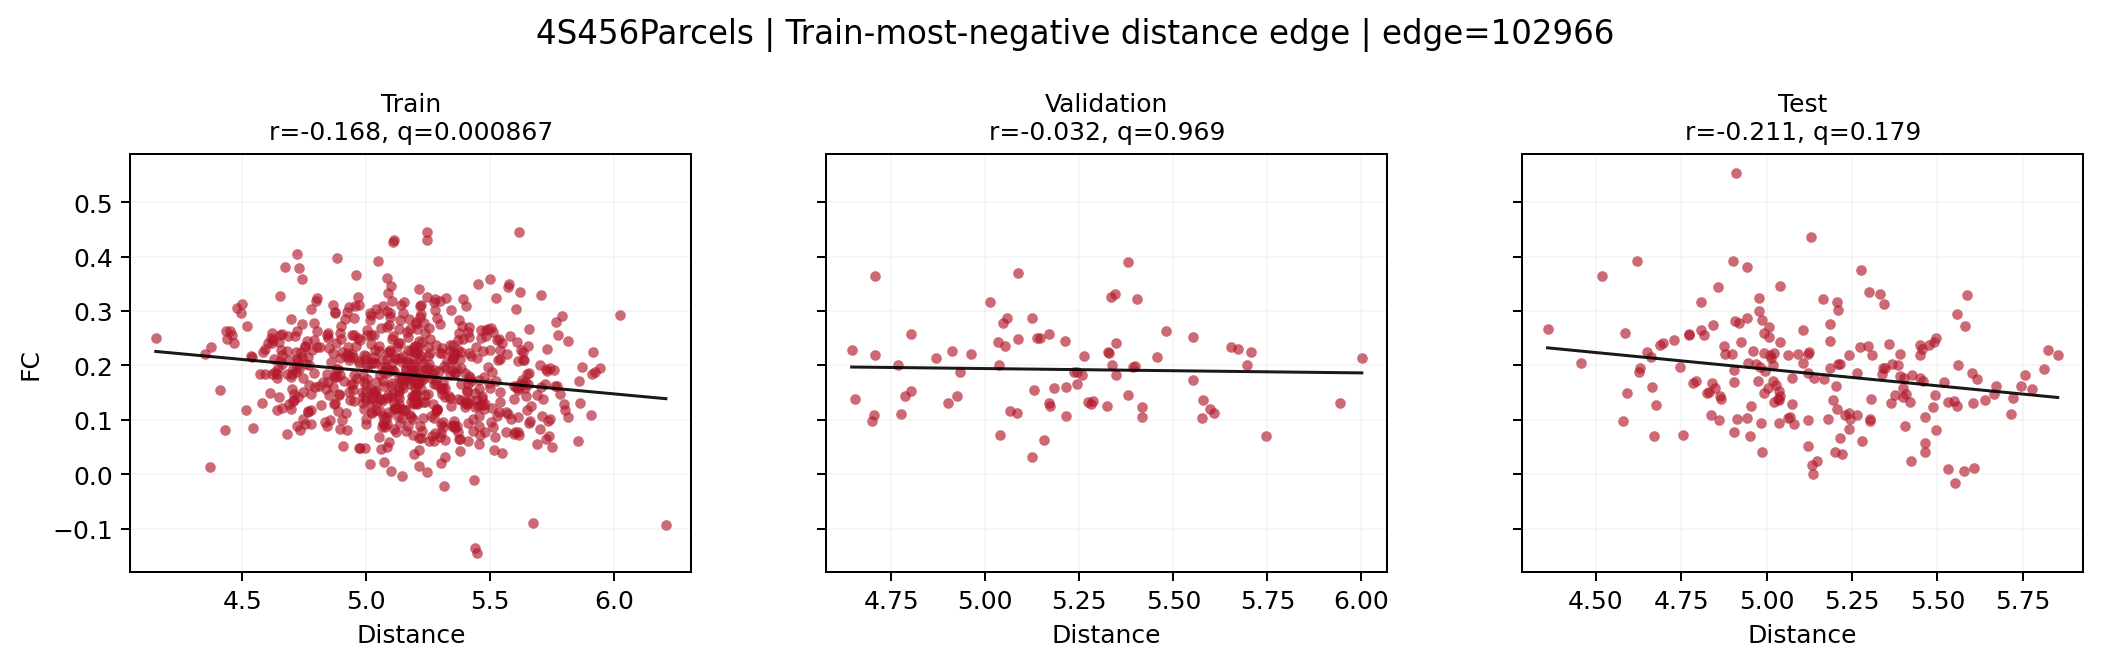

,edge_idx,slope,corr,r2,p_value,q_value,significant_fdr,distance_mean,label_i,label_j,hemisphere_i,hemisphere_j,network_label_i,network_label_j,network_label_17network_i,network_label_17network_j,same_hemisphere,same_network,same_network_17
102966,102966,-0.042146,-0.168403,0.028359,0.00001,0.000867,True,5.164323,RH-NAC,RH-VeP,R,R,NaN,NaN,NaN,NaN,True,False,False


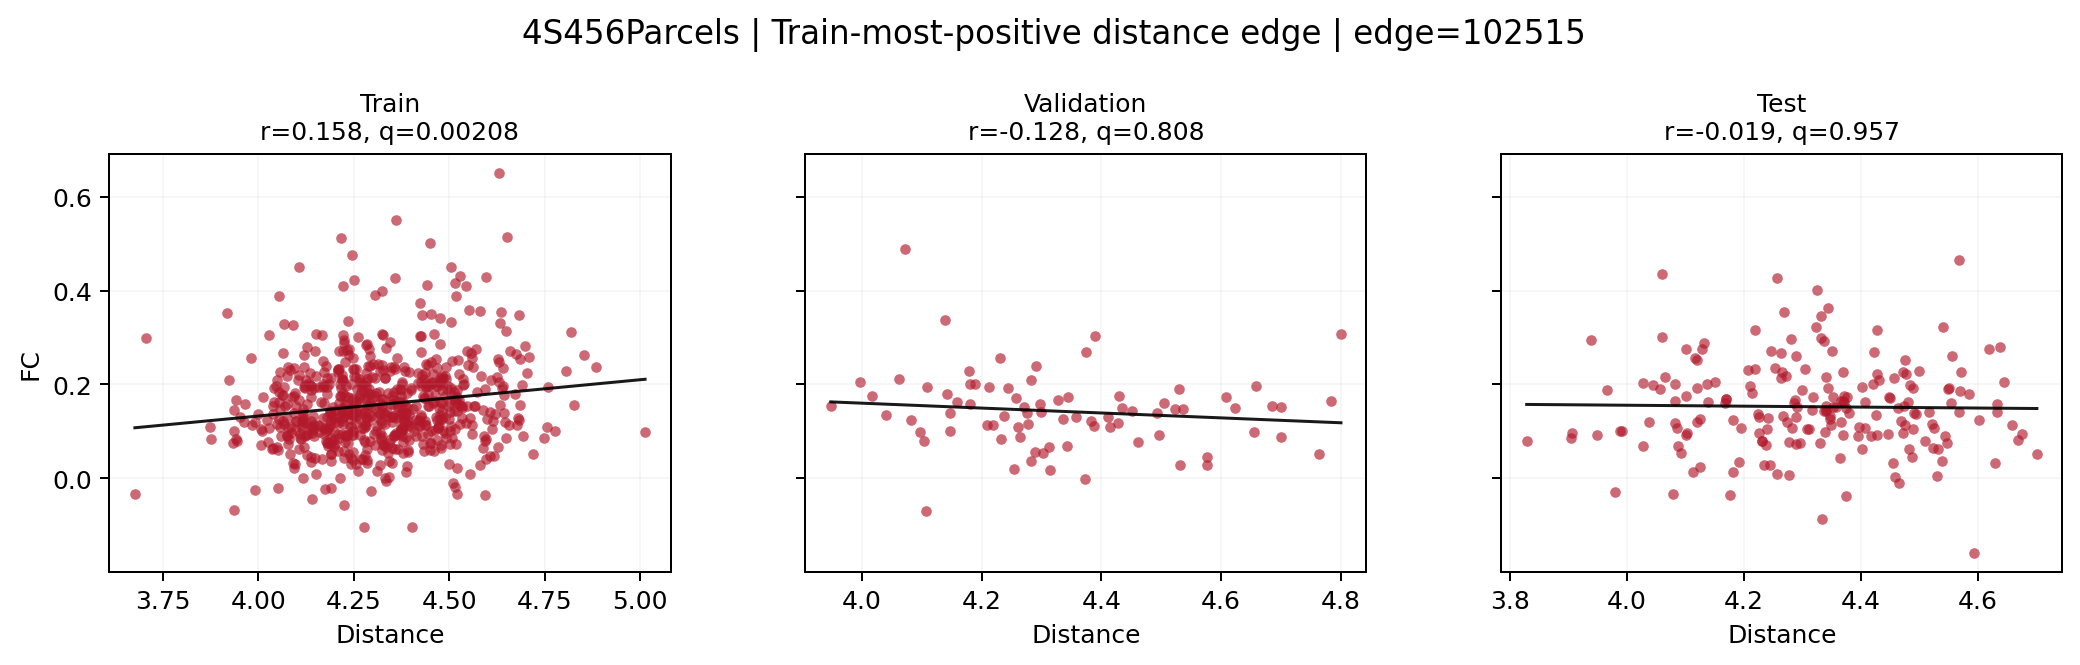

,edge_idx,slope,corr,r2,p_value,q_value,significant_fdr,distance_mean,label_i,label_j,hemisphere_i,hemisphere_j,network_label_i,network_label_j,network_label_17network_i,network_label_17network_j,same_hemisphere,same_network,same_network_17
102515,102515,0.077387,0.157501,0.024807,0.000036,0.002083,True,4.319142,LH-SNc_PBP_VTA,LH-RN,L,L,NaN,NaN,NaN,NaN,True,False,False


In [61]:
if len(train_distance_top_negative) > 0:
    negative_edge_idx = int(train_distance_top_negative.iloc[0]['edge_idx'])
    fig_neg, axes_neg, rows_neg = plot_single_edge_distance_scatter_across_partitions(
        base,
        edge_idx=negative_edge_idx,
        partitions=('train', 'val', 'test'),
        y_key='FC',
        suptitle=(
            f"{base.parcellation} | Train-most-negative distance edge | "
            f"edge={negative_edge_idx}"
        ),
    )
    display(train_distance_top_negative.head(1))
else:
    print('No FDR-significant negative distance edge found on train.')

if len(train_distance_top_positive) > 0:
    positive_edge_idx = int(train_distance_top_positive.iloc[0]['edge_idx'])
    fig_pos, axes_pos, rows_pos = plot_single_edge_distance_scatter_across_partitions(
        base,
        edge_idx=positive_edge_idx,
        partitions=('train', 'val', 'test'),
        y_key='FC',
        suptitle=(
            f"{base.parcellation} | Train-most-positive distance edge | "
            f"edge={positive_edge_idx}"
        ),
    )
    display(train_distance_top_positive.head(1))
else:
    print('No FDR-significant positive distance edge found on train.')


## Volume Block: Add Log Volume Terms Beyond Distance

Main volume model:
- reduced: `FC ~ distance`
- full: `FC ~ distance + log_product_volume + log_volume_mismatch`

Use a nested per-edge model comparison to ask whether the added log-volume block significantly improves fit beyond distance alone.


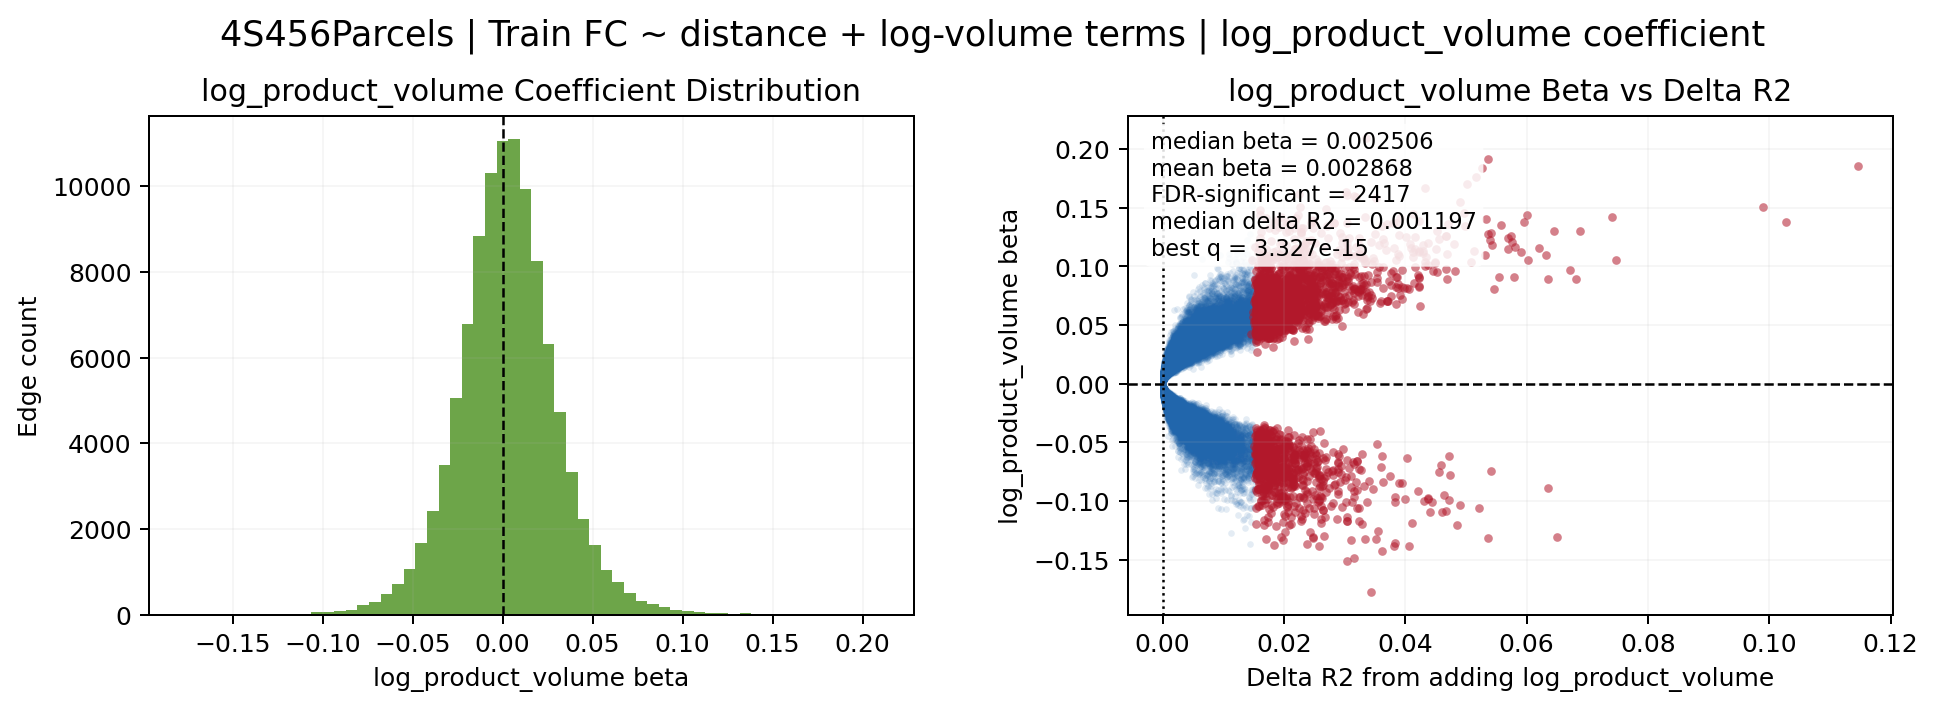

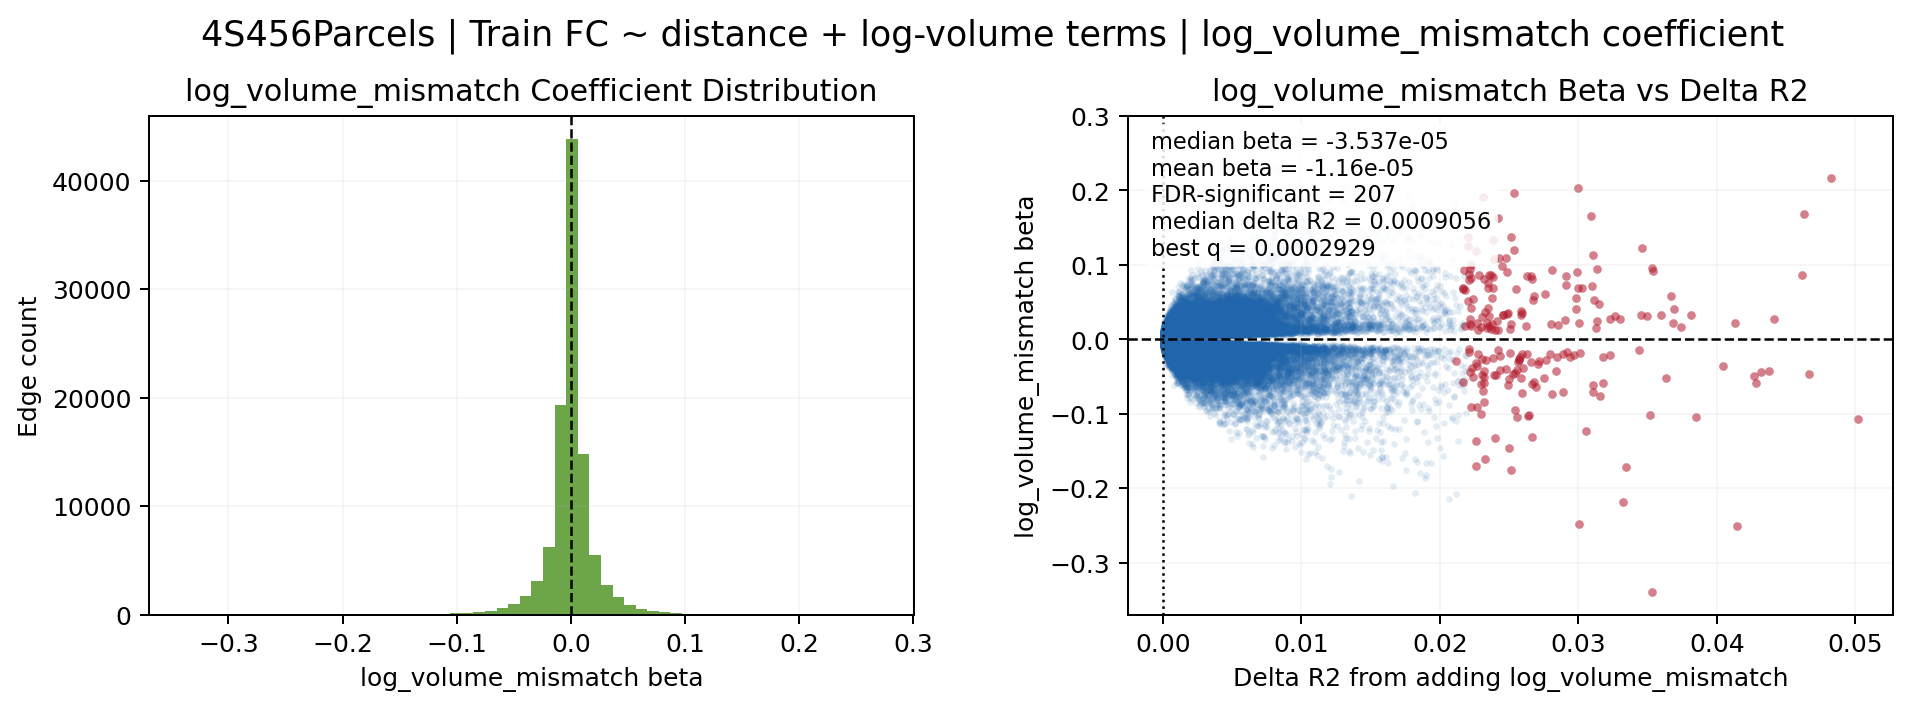

,r2_reduced,r2_full,delta_r2,f_stat,block_p_value,block_q_value
count,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000
mean,0.0041,0.0090,0.0049,1.6934,0.3871,0.6208
std,0.0061,0.0085,0.0055,1.9413,0.3034,0.2706
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0004,0.0033,0.0013,0.4451,0.1062,0.4250
50%,0.0018,0.0066,0.0032,1.0951,0.3351,0.6702
75%,0.0053,0.0120,0.0066,2.2494,0.6410,0.8546
max,0.0818,0.1397,0.1170,46.1871,1.0000,1.0000


In [62]:
train_fc_logvol_reg_df = compute_edgewise_multifeature_regression(
    base,
    partition='train',
    y_key='FC',
    model_name='distance_log_product_volume_log_volume_mismatch',
    fdr_alpha=0.05,
)

train_volume_block_df = compare_edgewise_models(
    train_fc_dist_reg_df,
    train_fc_logvol_reg_df,
    added_predictor_names=['log_product_volume', 'log_volume_mismatch'],
    fdr_alpha=0.05,
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_logvol_reg_df,
    coef_name='log_product_volume',
    suptitle=f"{base.parcellation} | Train FC ~ distance + log-volume terms | log_product_volume coefficient",
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_logvol_reg_df,
    coef_name='log_volume_mismatch',
    suptitle=f"{base.parcellation} | Train FC ~ distance + log-volume terms | log_volume_mismatch coefficient",
)

train_volume_block_df[['r2_reduced', 'r2_full', 'delta_r2', 'f_stat', 'block_p_value', 'block_q_value']].describe().round(4)


In [63]:
volume_block_display_cols = [
    'edge_idx', 'r2_reduced', 'r2_full', 'delta_r2', 'block_p_value', 'block_q_value', 'block_significant_fdr',
    'log_product_volume_beta', 'log_product_volume_delta_r2',
    'log_volume_mismatch_beta', 'log_volume_mismatch_delta_r2',
    'label_i', 'label_j',
    'network_label_i', 'network_label_j',
    'same_hemisphere', 'same_network',
]

train_volume_block_sig_df = train_volume_block_df[train_volume_block_df['block_significant_fdr']].copy()

print(f"Volume block FDR-significant edges on train: {len(train_volume_block_sig_df)}")
display(train_volume_block_sig_df.sort_values('block_q_value')[volume_block_display_cols].head(25))

print('Volume block significant edges sorted by delta R2')
display(train_volume_block_sig_df.sort_values('delta_r2', ascending=False)[volume_block_display_cols].head(25))

print('Volume block significant edges sorted by full-model R2')
display(train_volume_block_sig_df.sort_values('r2_full', ascending=False)[volume_block_display_cols].head(25))


Volume block FDR-significant edges on train: 2708


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,log_product_volume_beta,log_product_volume_delta_r2,log_volume_mismatch_beta,log_volume_mismatch_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
56769,56769,0.022693,0.139728,0.117035,1.560521e-19,1.618884e-14,True,0.185142,0.114607,0.002303,0.000242,LH_Default_Temp_2,LH_Default_Temp_3,Default,Default,True,True
46315,46315,0.029017,0.132334,0.103317,2.584379e-17,1.340518e-12,True,0.137865,0.102783,-0.019021,0.004859,LH_Limbic_OFC_4,RH_Limbic_OFC_5,Limbic,Limbic,False,True
48333,48333,0.001740,0.103902,0.102162,1.206417e-16,4.171790e-12,True,0.150733,0.099031,0.006560,0.000959,LH_Limbic_TempPole_5,RH_Limbic_TempPole_4,Limbic,Limbic,False,True
0,0,0.016361,0.114786,0.098425,2.852535e-16,7.398050e-12,True,0.130233,0.068800,0.014492,0.016666,LH_Vis_1,LH_Vis_2,Vis,Vis,True,True
29484,29484,0.000143,0.092783,0.092640,4.613048e-15,9.571152e-11,True,0.088804,0.068106,-0.035907,0.040433,LH_DorsAttn_Post_3,LH_Limbic_TempPole_3,DorsAttn,Limbic,True,False
29099,29099,0.000003,0.084402,0.084400,9.979071e-14,1.725381e-09,True,0.105495,0.074705,-0.038930,0.025983,LH_DorsAttn_Post_2,LH_Limbic_TempPole_3,DorsAttn,Limbic,True,False
47679,47679,0.004579,0.087152,0.082573,1.706146e-13,2.528508e-09,True,-0.131535,0.053638,0.020425,0.018960,LH_Limbic_TempPole_3,RH_Cont_PFCl_1,Limbic,Cont,False,False
95099,95099,0.000920,0.081011,0.080092,4.780483e-13,6.199091e-09,True,0.138806,0.024716,0.019725,0.000573,RH_Limbic_TempPole_1,RH_Limbic_TempPole_7,Limbic,Limbic,True,True
87140,87140,0.006671,0.082670,0.075999,1.838193e-12,2.118824e-08,True,0.089155,0.024641,0.021275,0.036813,RH_DorsAttn_Post_4,RH_Limbic_TempPole_4,DorsAttn,Limbic,True,False
100425,100425,0.012491,0.086609,0.074117,3.136002e-12,3.253289e-08,True,0.142234,0.074114,-0.024815,0.006270,RH_Default_PFCv_1,RH_Default_PFCdPFCm_4,Default,Default,True,True


Volume block significant edges sorted by delta R2


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,log_product_volume_beta,log_product_volume_delta_r2,log_volume_mismatch_beta,log_volume_mismatch_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
56769,56769,0.022693,0.139728,0.117035,1.560521e-19,1.618884e-14,True,0.185142,0.114607,0.002303,0.000242,LH_Default_Temp_2,LH_Default_Temp_3,Default,Default,True,True
46315,46315,0.029017,0.132334,0.103317,2.584379e-17,1.340518e-12,True,0.137865,0.102783,-0.019021,0.004859,LH_Limbic_OFC_4,RH_Limbic_OFC_5,Limbic,Limbic,False,True
48333,48333,0.001740,0.103902,0.102162,1.206417e-16,4.171790e-12,True,0.150733,0.099031,0.006560,0.000959,LH_Limbic_TempPole_5,RH_Limbic_TempPole_4,Limbic,Limbic,False,True
0,0,0.016361,0.114786,0.098425,2.852535e-16,7.398050e-12,True,0.130233,0.068800,0.014492,0.016666,LH_Vis_1,LH_Vis_2,Vis,Vis,True,True
29484,29484,0.000143,0.092783,0.092640,4.613048e-15,9.571152e-11,True,0.088804,0.068106,-0.035907,0.040433,LH_DorsAttn_Post_3,LH_Limbic_TempPole_3,DorsAttn,Limbic,True,False
29099,29099,0.000003,0.084402,0.084400,9.979071e-14,1.725381e-09,True,0.105495,0.074705,-0.038930,0.025983,LH_DorsAttn_Post_2,LH_Limbic_TempPole_3,DorsAttn,Limbic,True,False
47679,47679,0.004579,0.087152,0.082573,1.706146e-13,2.528508e-09,True,-0.131535,0.053638,0.020425,0.018960,LH_Limbic_TempPole_3,RH_Cont_PFCl_1,Limbic,Cont,False,False
95099,95099,0.000920,0.081011,0.080092,4.780483e-13,6.199091e-09,True,0.138806,0.024716,0.019725,0.000573,RH_Limbic_TempPole_1,RH_Limbic_TempPole_7,Limbic,Limbic,True,True
87140,87140,0.006671,0.082670,0.075999,1.838193e-12,2.118824e-08,True,0.089155,0.024641,0.021275,0.036813,RH_DorsAttn_Post_4,RH_Limbic_TempPole_4,DorsAttn,Limbic,True,False
100425,100425,0.012491,0.086609,0.074117,3.136002e-12,3.253289e-08,True,0.142234,0.074114,-0.024815,0.006270,RH_Default_PFCv_1,RH_Default_PFCdPFCm_4,Default,Default,True,True


Volume block significant edges sorted by full-model R2


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,log_product_volume_beta,log_product_volume_delta_r2,log_volume_mismatch_beta,log_volume_mismatch_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
56769,56769,0.022693,0.139728,0.117035,1.560521e-19,1.618884e-14,True,0.185142,0.114607,0.002303,0.000242,LH_Default_Temp_2,LH_Default_Temp_3,Default,Default,True,True
46315,46315,0.029017,0.132334,0.103317,2.584379e-17,1.340518e-12,True,0.137865,0.102783,-0.019021,0.004859,LH_Limbic_OFC_4,RH_Limbic_OFC_5,Limbic,Limbic,False,True
0,0,0.016361,0.114786,0.098425,2.852535e-16,7.398050e-12,True,0.130233,0.068800,0.014492,0.016666,LH_Vis_1,LH_Vis_2,Vis,Vis,True,True
47666,47666,0.064514,0.113092,0.048578,1.372957e-08,2.006064e-05,True,0.075208,0.032899,-0.030121,0.026574,LH_Limbic_TempPole_3,RH_Limbic_TempPole_4,Limbic,Limbic,False,True
47463,47463,0.076566,0.106093,0.029527,1.616225e-05,3.590304e-03,True,0.082154,0.029069,0.000413,0.000007,LH_Limbic_TempPole_3,LH_Limbic_TempPole_7,Limbic,Limbic,True,True
48333,48333,0.001740,0.103902,0.102162,1.206417e-16,4.171790e-12,True,0.150733,0.099031,0.006560,0.000959,LH_Limbic_TempPole_5,RH_Limbic_TempPole_4,Limbic,Limbic,False,True
29484,29484,0.000143,0.092783,0.092640,4.613048e-15,9.571152e-11,True,0.088804,0.068106,-0.035907,0.040433,LH_DorsAttn_Post_3,LH_Limbic_TempPole_3,DorsAttn,Limbic,True,False
61556,61556,0.045705,0.089582,0.043877,1.148349e-07,9.697873e-05,True,0.115773,0.038200,-0.057536,0.014958,LH_Default_PFC_1,LH_Default_PFC_13,Default,Default,True,True
56480,56480,0.044429,0.089179,0.044749,8.479323e-08,7.716184e-05,True,0.120026,0.043751,0.003394,0.000487,LH_Default_Temp_1,LH_Default_PFC_3,Default,Default,True,True
12233,12233,0.055441,0.088983,0.033542,4.665718e-06,1.480188e-03,True,0.049571,0.009584,0.052495,0.017395,LH_Vis_28,RH_Limbic_TempPole_4,Vis,Limbic,False,False


## Structural Connectivity Block: Raw SC vs Subject-Z SC

SC is already log-transformed in the cached dataset.
Compare two add-on models against the log-volume model:
- raw SC edge value
- subject-wise z-scored SC edge value

Again, use nested block tests rather than coefficient-only significance as the primary result.


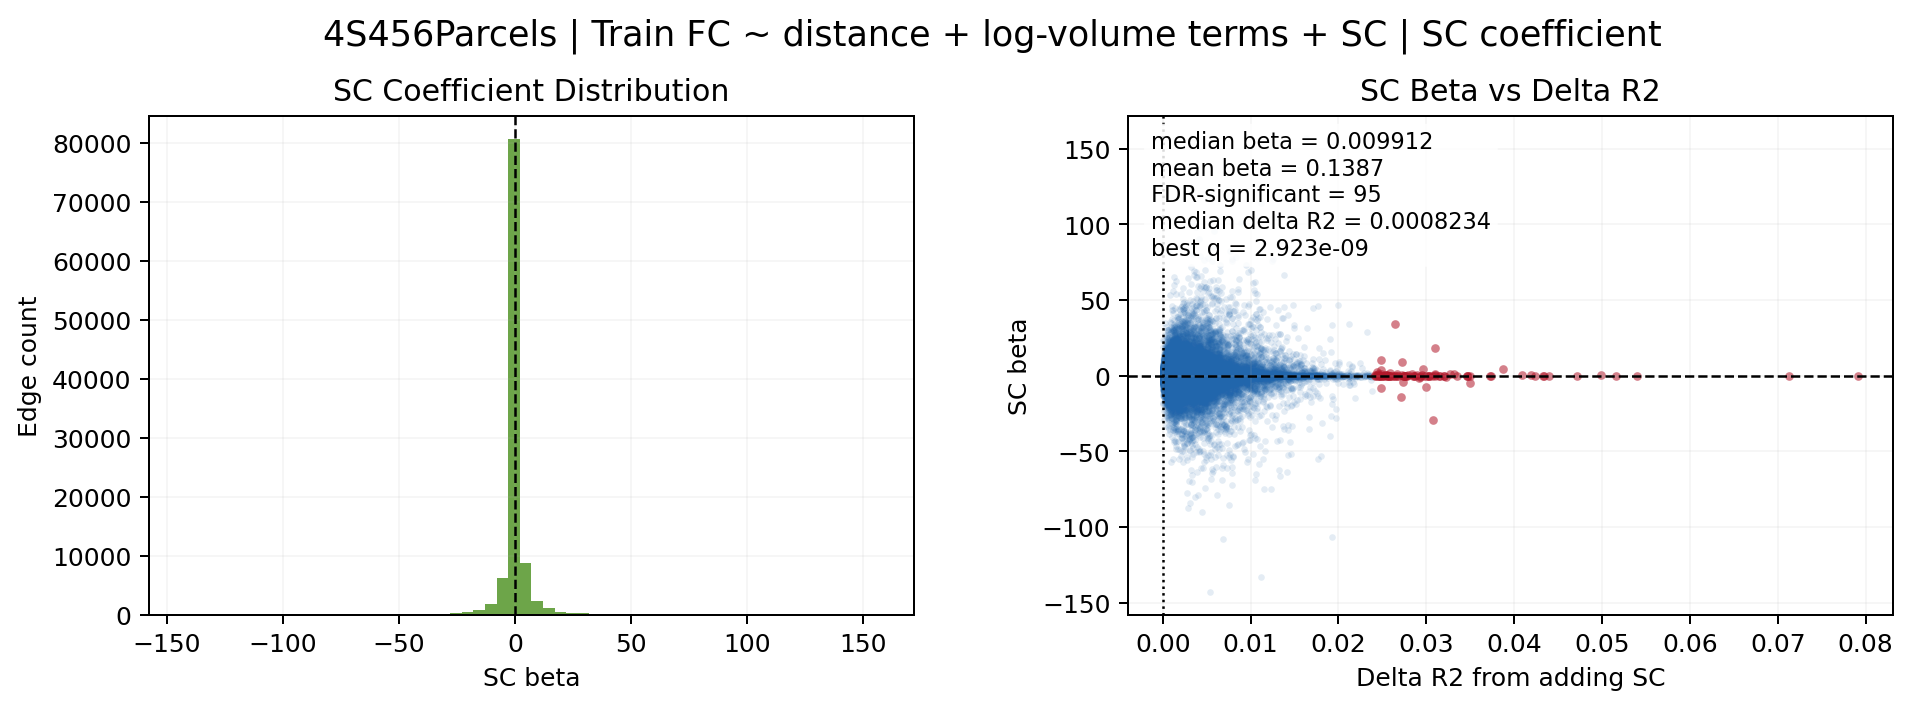

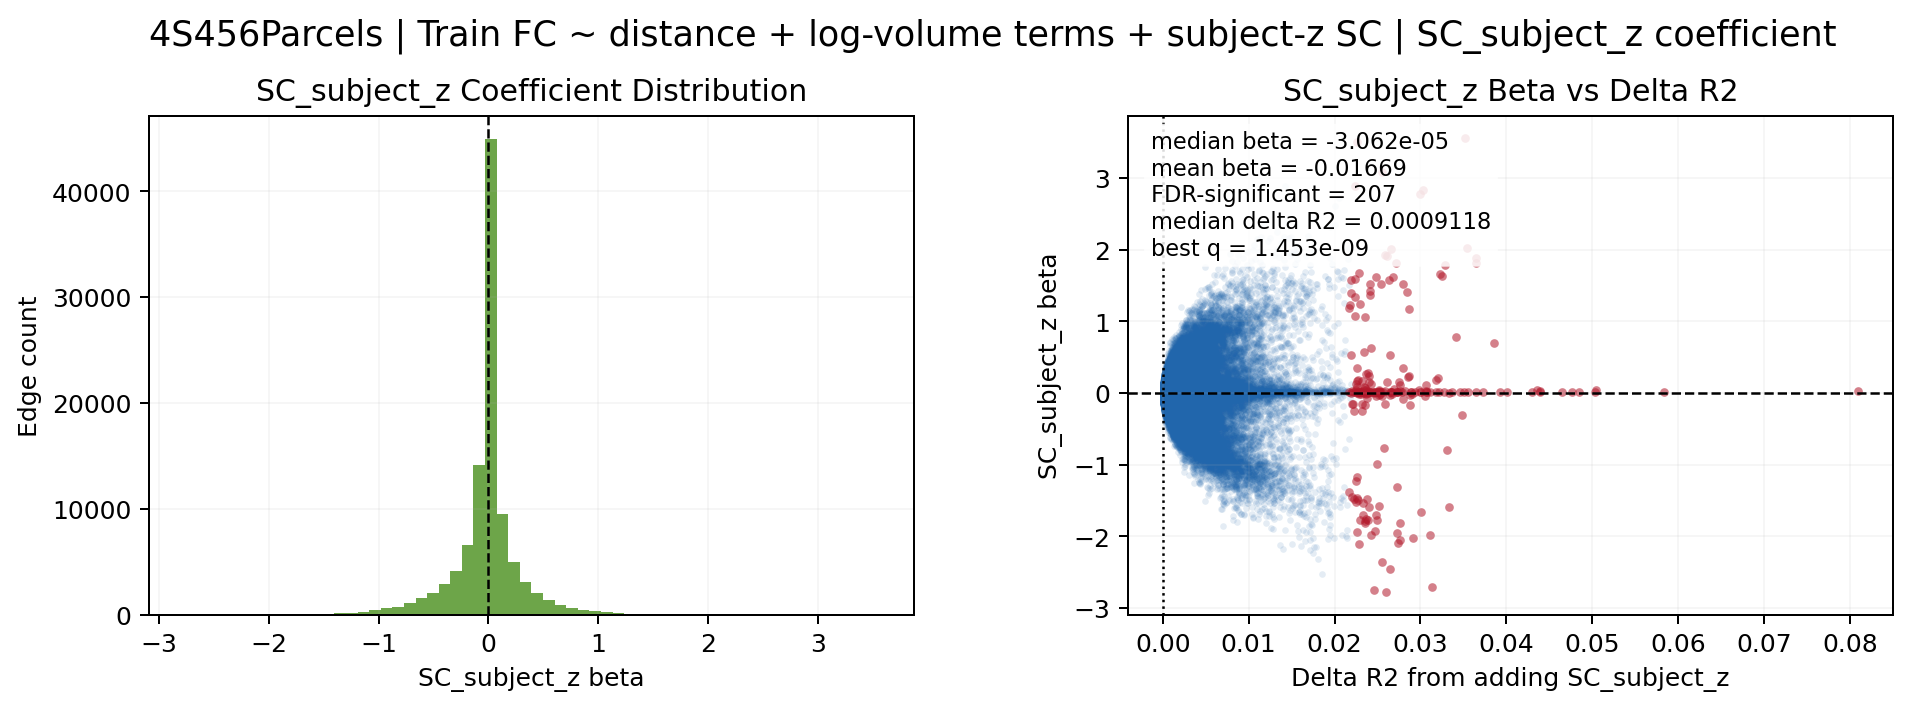

In [64]:
train_fc_logvol_sc_reg_df = compute_edgewise_multifeature_regression(
    base,
    partition='train',
    y_key='FC',
    model_name='distance_log_product_volume_log_volume_mismatch_sc',
    fdr_alpha=0.05,
)
train_sc_block_df = compare_edgewise_models(
    train_fc_logvol_reg_df,
    train_fc_logvol_sc_reg_df,
    added_predictor_names=['SC'],
    fdr_alpha=0.05,
)

train_fc_logvol_scz_reg_df = compute_edgewise_multifeature_regression(
    base,
    partition='train',
    y_key='FC',
    model_name='distance_log_product_volume_log_volume_mismatch_sc_subject_z',
    fdr_alpha=0.05,
)
train_scz_block_df = compare_edgewise_models(
    train_fc_logvol_reg_df,
    train_fc_logvol_scz_reg_df,
    added_predictor_names=['SC_subject_z'],
    fdr_alpha=0.05,
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_logvol_sc_reg_df,
    coef_name='SC',
    suptitle=f"{base.parcellation} | Train FC ~ distance + log-volume terms + SC | SC coefficient",
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_logvol_scz_reg_df,
    coef_name='SC_subject_z',
    suptitle=f"{base.parcellation} | Train FC ~ distance + log-volume terms + subject-z SC | SC_subject_z coefficient",
)


In [65]:
sc_block_display_cols = [
    'edge_idx', 'r2_reduced', 'r2_full', 'delta_r2', 'block_p_value', 'block_q_value', 'block_significant_fdr',
    'SC_beta', 'SC_delta_r2',
    'label_i', 'label_j',
    'network_label_i', 'network_label_j',
    'same_hemisphere', 'same_network',
]

scz_block_display_cols = [
    'edge_idx', 'r2_reduced', 'r2_full', 'delta_r2', 'block_p_value', 'block_q_value', 'block_significant_fdr',
    'SC_subject_z_beta', 'SC_subject_z_delta_r2',
    'label_i', 'label_j',
    'network_label_i', 'network_label_j',
    'same_hemisphere', 'same_network',
]

train_sc_block_sig_df = train_sc_block_df[train_sc_block_df['block_significant_fdr']].copy()
train_scz_block_sig_df = train_scz_block_df[train_scz_block_df['block_significant_fdr']].copy()

print(f"Raw SC block FDR-significant edges on train: {len(train_sc_block_sig_df)}")
display(train_sc_block_sig_df.sort_values('block_q_value')[sc_block_display_cols].head(25))
print('Raw SC block significant edges sorted by delta R2')
display(train_sc_block_sig_df.sort_values('delta_r2', ascending=False)[sc_block_display_cols].head(25))

print(f"Subject-z SC block FDR-significant edges on train: {len(train_scz_block_sig_df)}")
display(train_scz_block_sig_df.sort_values('block_q_value')[scz_block_display_cols].head(25))
print('Subject-z SC block significant edges sorted by delta R2')
display(train_scz_block_sig_df.sort_values('delta_r2', ascending=False)[scz_block_display_cols].head(25))


Raw SC block FDR-significant edges on train: 95


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,SC_beta,SC_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
31731,31731,0.033175,0.112313,0.079138,2.818105e-14,2.923502e-09,True,0.162618,0.079138,LH_DorsAttn_Post_9,LH_DorsAttn_Post_11,DorsAttn,DorsAttn,True,True
51431,51431,0.037833,0.109107,0.071274,5.159910e-13,2.676445e-08,True,0.100207,0.071274,LH_Cont_Temp_1,LH_Default_Temp_3,Cont,Default,True,False
65792,65792,0.004736,0.058733,0.053997,7.870716e-10,2.721694e-05,True,0.080349,0.053997,LH_Default_PFC_16,LH_Default_PFC_19,Default,Default,True,True
96719,96719,0.009733,0.061289,0.051556,1.759094e-09,4.562209e-05,True,0.088605,0.051556,RH_Cont_Temp_1,RH_Cont_Temp_2,Cont,Cont,True,True
11552,11552,0.004301,0.054137,0.049836,3.676704e-09,7.628426e-05,True,0.245098,0.049836,LH_Vis_27,LH_DorsAttn_Post_7,Vis,DorsAttn,True,False
79924,79924,0.023020,0.070202,0.047182,6.998460e-09,1.210034e-04,True,0.135131,0.047182,RH_SomMot_8,RH_SalVentAttn_TempOccPar_1,SomMot,SalVentAttn,True,False
90537,90537,0.066541,0.110493,0.043952,1.088875e-08,1.613713e-04,True,0.128909,0.043952,RH_SalVentAttn_TempOccPar_1,RH_SalVentAttn_TempOccPar_2,SalVentAttn,SalVentAttn,True,True
62700,62700,0.015076,0.058361,0.043286,3.427219e-08,3.950441e-04,True,0.083422,0.043286,LH_Default_PFC_5,LH_Default_PFC_7,Default,Default,True,True
24357,24357,0.014209,0.057590,0.043380,3.356258e-08,3.950441e-04,True,0.098029,0.043380,LH_SomMot_27,LH_DorsAttn_Post_9,SomMot,DorsAttn,True,False
11550,11550,0.020246,0.062596,0.042350,4.462951e-08,4.629866e-04,True,0.092914,0.042350,LH_Vis_27,LH_DorsAttn_Post_5,Vis,DorsAttn,True,False


Raw SC block significant edges sorted by delta R2


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,SC_beta,SC_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
31731,31731,0.033175,0.112313,0.079138,2.818105e-14,2.923502e-09,True,0.162618,0.079138,LH_DorsAttn_Post_9,LH_DorsAttn_Post_11,DorsAttn,DorsAttn,True,True
51431,51431,0.037833,0.109107,0.071274,5.159910e-13,2.676445e-08,True,0.100207,0.071274,LH_Cont_Temp_1,LH_Default_Temp_3,Cont,Default,True,False
65792,65792,0.004736,0.058733,0.053997,7.870716e-10,2.721694e-05,True,0.080349,0.053997,LH_Default_PFC_16,LH_Default_PFC_19,Default,Default,True,True
96719,96719,0.009733,0.061289,0.051556,1.759094e-09,4.562209e-05,True,0.088605,0.051556,RH_Cont_Temp_1,RH_Cont_Temp_2,Cont,Cont,True,True
11552,11552,0.004301,0.054137,0.049836,3.676704e-09,7.628426e-05,True,0.245098,0.049836,LH_Vis_27,LH_DorsAttn_Post_7,Vis,DorsAttn,True,False
79924,79924,0.023020,0.070202,0.047182,6.998460e-09,1.210034e-04,True,0.135131,0.047182,RH_SomMot_8,RH_SalVentAttn_TempOccPar_1,SomMot,SalVentAttn,True,False
90537,90537,0.066541,0.110493,0.043952,1.088875e-08,1.613713e-04,True,0.128909,0.043952,RH_SalVentAttn_TempOccPar_1,RH_SalVentAttn_TempOccPar_2,SalVentAttn,SalVentAttn,True,True
24357,24357,0.014209,0.057590,0.043380,3.356258e-08,3.950441e-04,True,0.098029,0.043380,LH_SomMot_27,LH_DorsAttn_Post_9,SomMot,DorsAttn,True,False
62700,62700,0.015076,0.058361,0.043286,3.427219e-08,3.950441e-04,True,0.083422,0.043286,LH_Default_PFC_5,LH_Default_PFC_7,Default,Default,True,True
11550,11550,0.020246,0.062596,0.042350,4.462951e-08,4.629866e-04,True,0.092914,0.042350,LH_Vis_27,LH_DorsAttn_Post_5,Vis,DorsAttn,True,False


Subject-z SC block FDR-significant edges on train: 207


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,SC_subject_z_beta,SC_subject_z_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
31731,31731,0.033175,0.114113,0.080938,1.400800e-14,1.453190e-09,True,0.026373,0.080938,LH_DorsAttn_Post_9,LH_DorsAttn_Post_11,DorsAttn,DorsAttn,True,True
51431,51431,0.037833,0.096168,0.058335,7.538785e-11,3.910368e-06,True,0.014808,0.058335,LH_Cont_Temp_1,LH_Default_Temp_3,Cont,Default,True,False
11552,11552,0.004301,0.054754,0.050453,2.930028e-09,7.599027e-05,True,0.039171,0.050453,LH_Vis_27,LH_DorsAttn_Post_7,Vis,DorsAttn,True,False
96719,96719,0.009733,0.060054,0.050321,2.778398e-09,7.599027e-05,True,0.014480,0.050321,RH_Cont_Temp_1,RH_Cont_Temp_2,Cont,Cont,True,True
90537,90537,0.066541,0.113055,0.046515,3.986048e-09,8.270251e-05,True,0.021499,0.046515,RH_SalVentAttn_TempOccPar_1,RH_SalVentAttn_TempOccPar_2,SalVentAttn,SalVentAttn,True,True
79924,79924,0.023020,0.070645,0.047625,5.927786e-09,8.946699e-05,True,0.021621,0.047625,RH_SomMot_8,RH_SalVentAttn_TempOccPar_1,SomMot,SalVentAttn,True,False
65792,65792,0.004736,0.053202,0.048466,6.036909e-09,8.946699e-05,True,0.012460,0.048466,LH_Default_PFC_16,LH_Default_PFC_19,Default,Default,True,True
24357,24357,0.014209,0.058187,0.043978,2.689517e-08,3.235348e-04,True,0.015990,0.043978,LH_SomMot_27,LH_DorsAttn_Post_9,SomMot,DorsAttn,True,False
9830,9830,0.021985,0.065502,0.043517,2.806838e-08,3.235348e-04,True,0.036032,0.043517,LH_Vis_23,LH_DorsAttn_Post_7,Vis,DorsAttn,True,False
11550,11550,0.020246,0.063204,0.042958,3.558472e-08,3.355963e-04,True,0.014851,0.042958,LH_Vis_27,LH_DorsAttn_Post_5,Vis,DorsAttn,True,False


Subject-z SC block significant edges sorted by delta R2


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,SC_subject_z_beta,SC_subject_z_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
31731,31731,0.033175,0.114113,0.080938,1.400800e-14,1.453190e-09,True,0.026373,0.080938,LH_DorsAttn_Post_9,LH_DorsAttn_Post_11,DorsAttn,DorsAttn,True,True
51431,51431,0.037833,0.096168,0.058335,7.538785e-11,3.910368e-06,True,0.014808,0.058335,LH_Cont_Temp_1,LH_Default_Temp_3,Cont,Default,True,False
11552,11552,0.004301,0.054754,0.050453,2.930028e-09,7.599027e-05,True,0.039171,0.050453,LH_Vis_27,LH_DorsAttn_Post_7,Vis,DorsAttn,True,False
96719,96719,0.009733,0.060054,0.050321,2.778398e-09,7.599027e-05,True,0.014480,0.050321,RH_Cont_Temp_1,RH_Cont_Temp_2,Cont,Cont,True,True
65792,65792,0.004736,0.053202,0.048466,6.036909e-09,8.946699e-05,True,0.012460,0.048466,LH_Default_PFC_16,LH_Default_PFC_19,Default,Default,True,True
79924,79924,0.023020,0.070645,0.047625,5.927786e-09,8.946699e-05,True,0.021621,0.047625,RH_SomMot_8,RH_SalVentAttn_TempOccPar_1,SomMot,SalVentAttn,True,False
90537,90537,0.066541,0.113055,0.046515,3.986048e-09,8.270251e-05,True,0.021499,0.046515,RH_SalVentAttn_TempOccPar_1,RH_SalVentAttn_TempOccPar_2,SalVentAttn,SalVentAttn,True,True
24357,24357,0.014209,0.058187,0.043978,2.689517e-08,3.235348e-04,True,0.015990,0.043978,LH_SomMot_27,LH_DorsAttn_Post_9,SomMot,DorsAttn,True,False
78681,78681,0.001536,0.045508,0.043972,3.314887e-08,3.355963e-04,True,0.028076,0.043972,RH_SomMot_2,RH_Default_Temp_8,SomMot,Default,True,False
9830,9830,0.021985,0.065502,0.043517,2.806838e-08,3.235348e-04,True,0.036032,0.043517,LH_Vis_23,LH_DorsAttn_Post_7,Vis,DorsAttn,True,False


In [66]:
train_sc_block_sig_df.describe()

,edge_idx,r2_reduced,r2_full,delta_r2,f_stat,block_p_value,block_q_value,fdr_alpha,distance_beta,distance_se,...,log_volume_mismatch_t_stat,log_volume_mismatch_p_value,log_volume_mismatch_delta_r2,log_volume_mismatch_q_value,SC_beta,SC_se,SC_t_stat,SC_p_value,SC_delta_r2,SC_q_value
count,95.000000,95.000000,95.000000,95.000000,95.000000,9.500000e+01,9.500000e+01,9.500000e+01,95.000000,95.000000,...,95.000000,95.000000,9.500000e+01,95.000000,95.000000,95.000000,95.000000,9.500000e+01,95.000000,9.500000e+01
mean,58080.294737,0.011635,0.042942,0.031307,22.273613,1.335276e-05,2.042538e-02,5.000000e-02,-0.000954,0.004270,...,-0.023752,0.417038,2.720811e-03,0.762701,0.324379,0.417938,2.693115,1.335276e-05,0.031307,2.042498e-02
std,32966.904942,0.011200,0.016511,0.009137,7.068245,1.325690e-05,1.463948e-02,2.092712e-17,0.009199,0.003113,...,1.402982,0.320747,4.363567e-03,0.231180,5.623445,1.192899,3.896221,1.325690e-05,0.009137,1.463920e-02
min,1819.000000,0.000830,0.025831,0.024185,16.921698,2.818105e-14,2.923502e-09,5.000000e-02,-0.041242,0.000938,...,-4.468676,0.000009,2.281228e-07,0.013575,-29.077660,0.009261,-4.961365,2.818105e-14,0.024185,2.923446e-09
25%,30675.500000,0.004346,0.032865,0.025788,18.168878,2.309941e-06,9.777138e-03,5.000000e-02,-0.002488,0.002005,...,-0.865432,0.111999,2.010548e-04,0.631266,0.048986,0.016329,4.132283,2.309941e-06,0.025788,9.776950e-03
50%,65792.000000,0.008893,0.038271,0.028603,20.246214,8.011436e-06,1.731472e-02,5.000000e-02,-0.000021,0.003363,...,-0.023914,0.358685,1.196948e-03,0.832605,0.088605,0.028261,4.343325,8.011436e-06,0.028603,1.731438e-02
75%,88558.000000,0.015342,0.047336,0.032113,22.708235,2.308102e-05,3.318850e-02,5.000000e-02,0.002836,0.005892,...,0.923988,0.704427,3.565262e-03,0.948562,0.223042,0.198574,4.714501,2.308102e-05,0.032113,3.318786e-02
max,102414.000000,0.066541,0.112313,0.079138,60.444054,4.374218e-05,4.776646e-02,5.000000e-02,0.019168,0.019247,...,2.836710,0.989927,2.619857e-02,0.998622,34.463081,7.990425,7.774577,4.374218e-05,0.079138,4.776554e-02


In [67]:
train_scz_block_sig_df.describe()

,edge_idx,r2_reduced,r2_full,delta_r2,f_stat,block_p_value,block_q_value,fdr_alpha,distance_beta,distance_se,...,log_volume_mismatch_t_stat,log_volume_mismatch_p_value,log_volume_mismatch_delta_r2,log_volume_mismatch_q_value,SC_subject_z_beta,SC_subject_z_se,SC_subject_z_t_stat,SC_subject_z_p_value,SC_subject_z_delta_r2,SC_subject_z_q_value
count,207.000000,207.000000,207.000000,207.000000,207.000000,2.070000e+02,2.070000e+02,2.070000e+02,207.000000,207.000000,...,207.000000,207.000000,2.070000e+02,207.000000,207.000000,207.000000,207.000000,2.070000e+02,207.000000,2.070000e+02
mean,57331.222222,0.014081,0.041783,0.027702,19.655865,3.353628e-05,2.487436e-02,5.000000e-02,-0.000630,0.003329,...,0.108689,0.412026,2.481078e-03,0.769691,0.004305,0.166771,1.787199,3.353628e-05,0.027702,2.487436e-02
std,33326.041275,0.013207,0.015874,0.007174,5.457534,2.954256e-05,1.487066e-02,1.391143e-17,0.007044,0.002670,...,1.328226,0.309196,3.665047e-03,0.215066,1.144622,0.206852,4.067149,2.954256e-05,0.007174,1.487066e-02
min,1143.000000,0.000476,0.022717,0.021695,15.324579,1.400800e-14,1.453190e-09,5.000000e-02,-0.041568,0.000698,...,-4.591551,0.000005,1.605909e-07,0.011103,-2.774470,0.001500,-4.985712,1.400800e-14,0.021695,1.453190e-09
25%,26917.500000,0.004990,0.030131,0.023388,16.434540,5.759073e-06,1.137438e-02,5.000000e-02,-0.002244,0.001503,...,-0.764934,0.130201,2.513706e-04,0.655779,-0.057130,0.003368,-4.003389,5.759073e-06,0.023388,1.137438e-02
50%,60070.000000,0.010028,0.037860,0.025361,17.908768,2.636613e-05,2.630021e-02,5.000000e-02,0.000062,0.002177,...,0.131621,0.368783,1.122591e-03,0.837680,0.013765,0.036989,4.085488,2.636613e-05,0.025361,2.630021e-02
75%,89910.500000,0.018286,0.048559,0.029265,20.897447,5.620081e-05,3.749360e-02,5.000000e-02,0.002081,0.004357,...,0.969423,0.674735,3.259577e-03,0.941566,0.178225,0.360258,4.461475,5.620081e-05,0.029265,3.749360e-02
max,102414.000000,0.070317,0.114113,0.080938,61.944561,9.967732e-05,4.995423e-02,5.000000e-02,0.018525,0.019294,...,3.011866,0.991575,2.757945e-02,0.998683,3.557074,0.870450,7.870487,9.967732e-05,0.080938,4.995423e-02


Median delta R2 from raw SC: 0.0008234
Median delta R2 from subject-z SC: 0.0009118


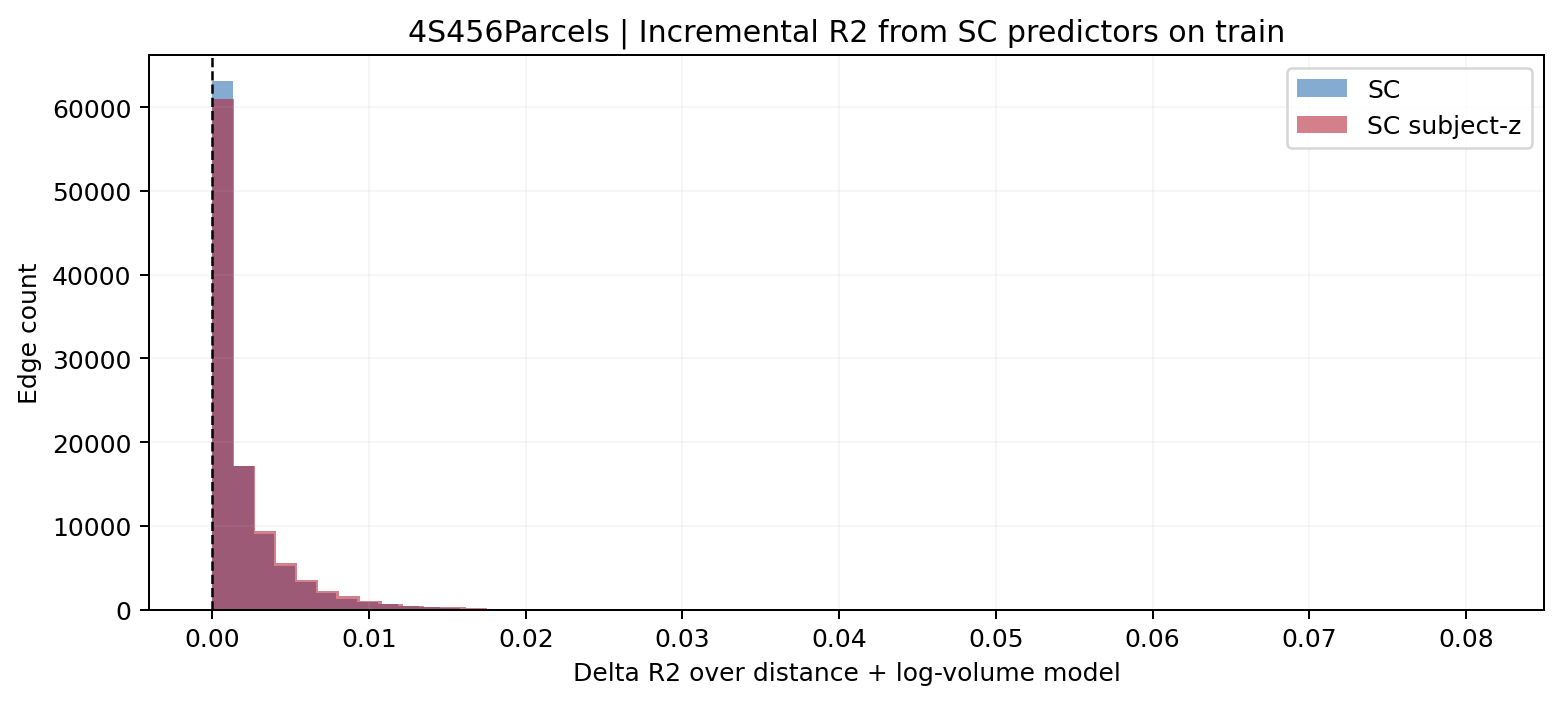

,r2_log_volume,r2_log_volume_plus_sc,r2_log_volume_plus_sc_subject_z,delta_r2_sc,delta_r2_sc_subject_z
count,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000
mean,0.0090,0.0109,0.0111,0.0018,0.0020
std,0.0085,0.0090,0.0092,0.0028,0.0030
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0033,0.0047,0.0048,0.0002,0.0002
50%,0.0066,0.0085,0.0086,0.0008,0.0009
75%,0.0120,0.0143,0.0145,0.0024,0.0027
max,0.1397,0.1510,0.1506,0.0791,0.0809


In [68]:
sc_compare_df = pd.DataFrame({
    'edge_idx': train_fc_logvol_reg_df['edge_idx'],
    'r2_log_volume': train_fc_logvol_reg_df['r2'],
    'r2_log_volume_plus_sc': train_fc_logvol_sc_reg_df['r2'],
    'r2_log_volume_plus_sc_subject_z': train_fc_logvol_scz_reg_df['r2'],
})
sc_compare_df['delta_r2_sc'] = sc_compare_df['r2_log_volume_plus_sc'] - sc_compare_df['r2_log_volume']
sc_compare_df['delta_r2_sc_subject_z'] = sc_compare_df['r2_log_volume_plus_sc_subject_z'] - sc_compare_df['r2_log_volume']

print(f"Median delta R2 from raw SC: {sc_compare_df['delta_r2_sc'].median():.4g}")
print(f"Median delta R2 from subject-z SC: {sc_compare_df['delta_r2_sc_subject_z'].median():.4g}")

plt.figure(figsize=(10, 4), dpi=180)
plt.hist(sc_compare_df['delta_r2_sc'], bins=60, alpha=0.55, label='SC', color='#2166ac')
plt.hist(sc_compare_df['delta_r2_sc_subject_z'], bins=60, alpha=0.55, label='SC subject-z', color='#b2182b')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Delta R2 over distance + log-volume model')
plt.ylabel('Edge count')
plt.title(f'{base.parcellation} | Incremental R2 from SC predictors on train')
plt.legend()
plt.grid(alpha=0.15, linewidth=0.6)
plt.show()

sc_compare_df[['r2_log_volume', 'r2_log_volume_plus_sc', 'r2_log_volume_plus_sc_subject_z', 'delta_r2_sc', 'delta_r2_sc_subject_z']].describe().round(4)


## Structural Connectivity and Combined Benchmarks

Benchmark models for SC alone and distance+SC, so the final R2 summary can compare geometry-only, structure-only, and combined structure-geometry models alongside the volume models.


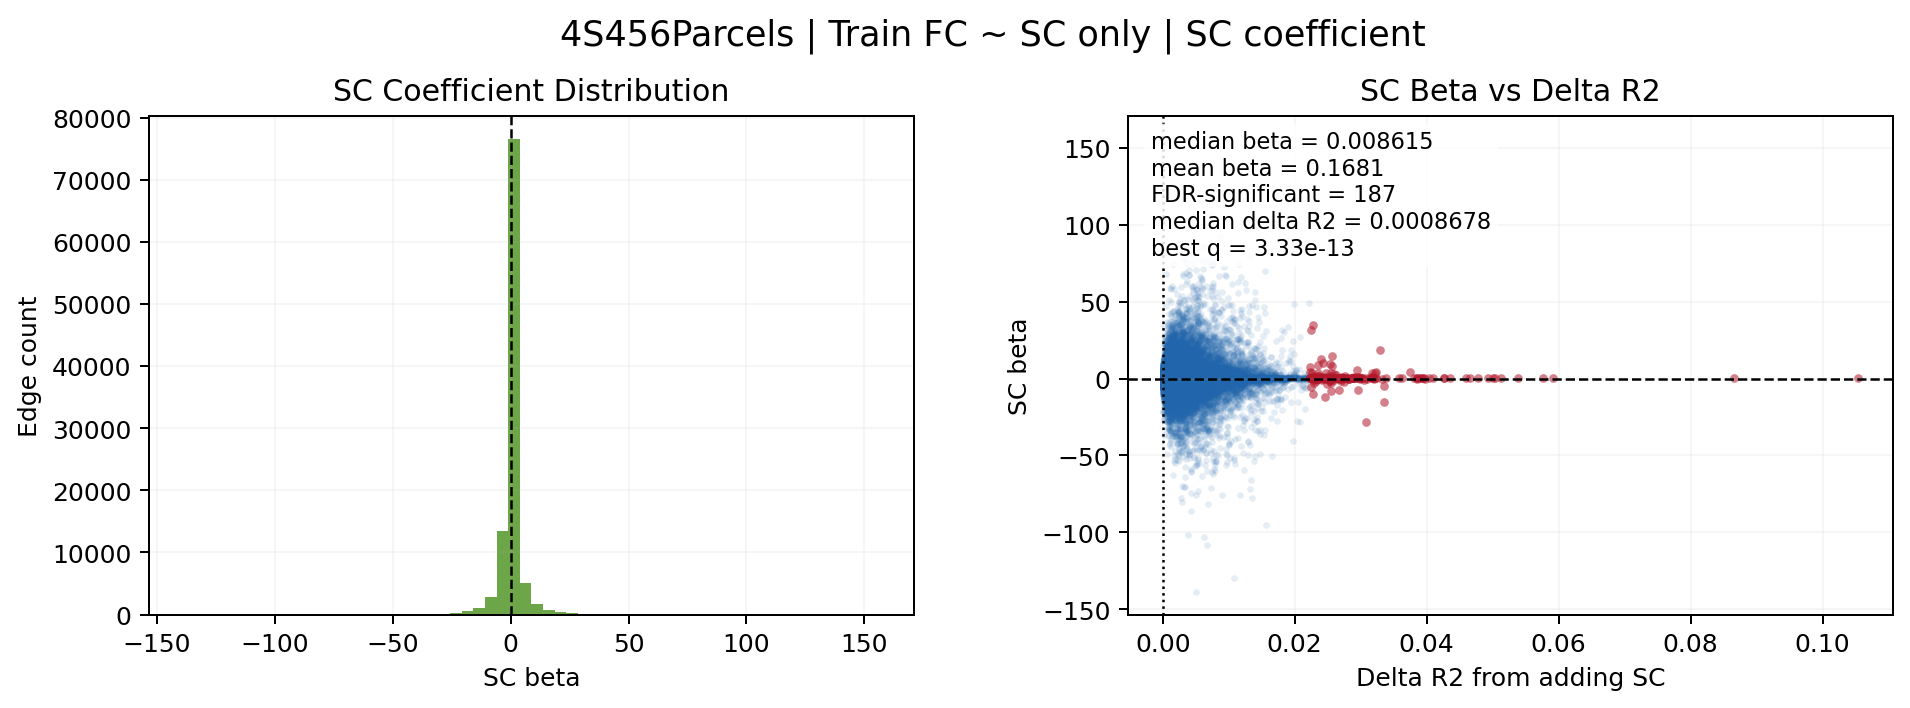

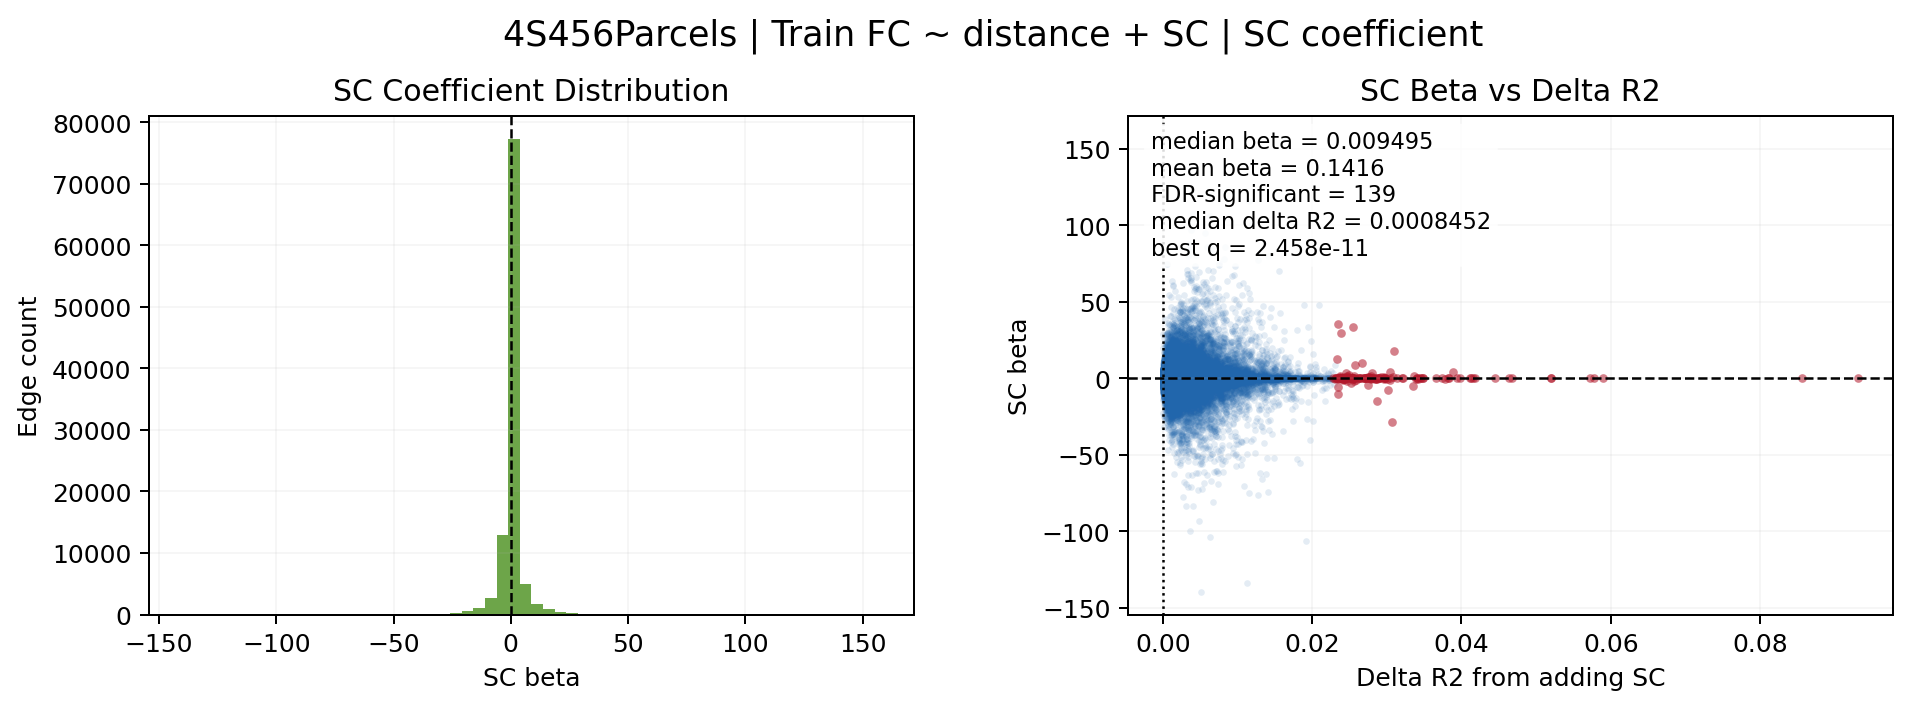

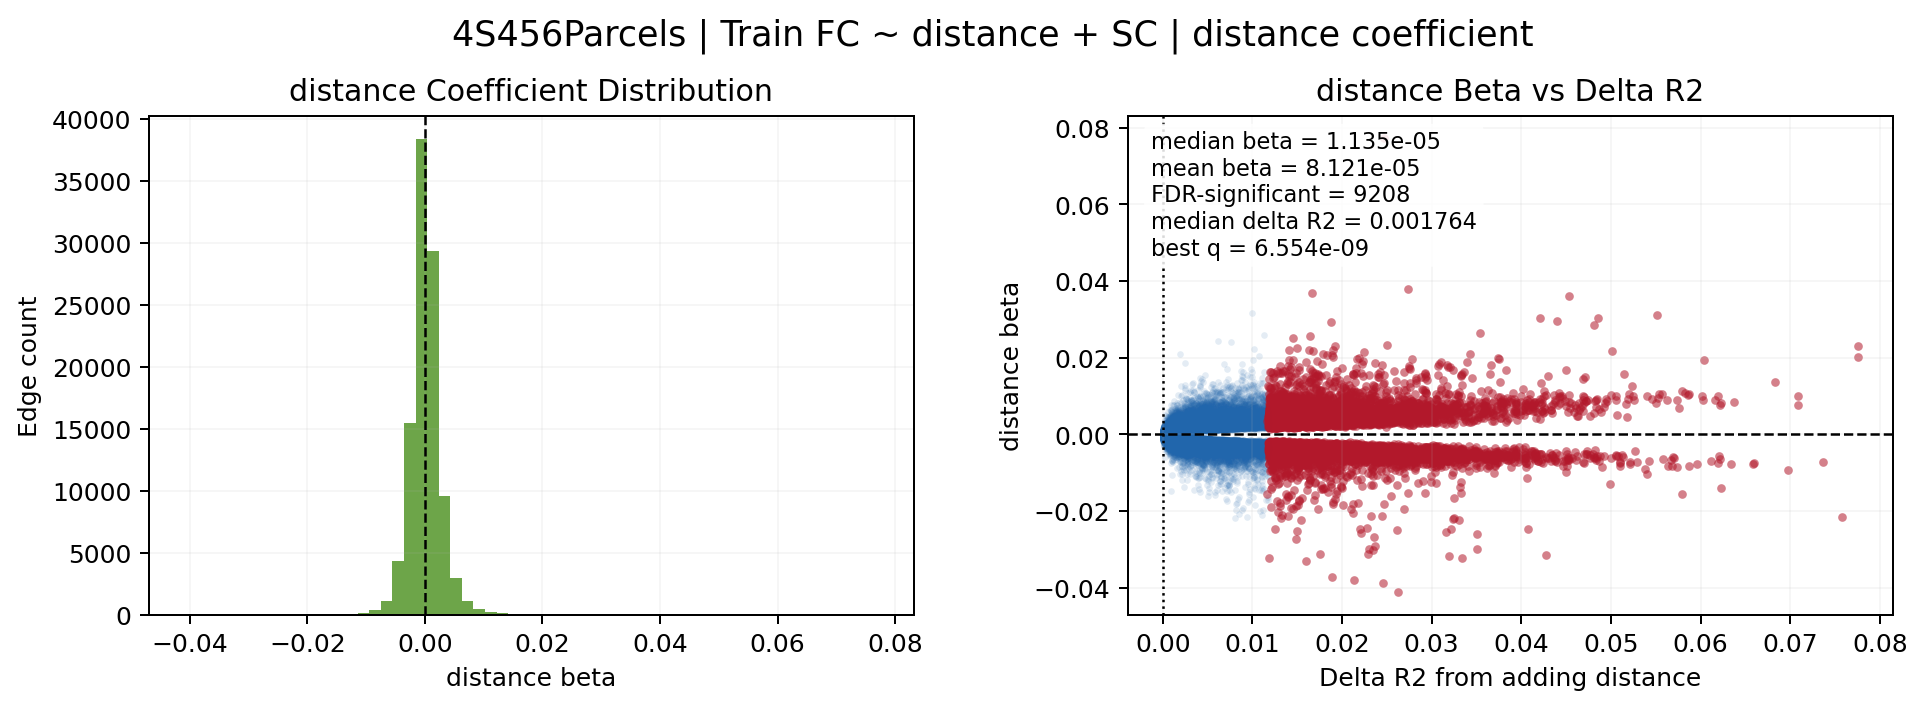

In [69]:
train_fc_sc_reg_df = compute_edgewise_multifeature_regression(
    base,
    partition='train',
    y_key='FC',
    model_name='sc',
    fdr_alpha=0.05,
)

train_fc_dist_sc_reg_df = compute_edgewise_multifeature_regression(
    base,
    partition='train',
    y_key='FC',
    model_name='distance_sc',
    fdr_alpha=0.05,
)

train_dist_sc_block_df = compare_edgewise_models(
    train_fc_sc_reg_df,
    train_fc_dist_sc_reg_df,
    added_predictor_names=['distance'],
    fdr_alpha=0.05,
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_sc_reg_df,
    coef_name='SC',
    suptitle=f"{base.parcellation} | Train FC ~ SC only | SC coefficient",
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_dist_sc_reg_df,
    coef_name='SC',
    suptitle=f"{base.parcellation} | Train FC ~ distance + SC | SC coefficient",
)

fig, axes = plot_multifeature_regression_summary(
    train_fc_dist_sc_reg_df,
    coef_name='distance',
    suptitle=f"{base.parcellation} | Train FC ~ distance + SC | distance coefficient",
)


In [70]:
dist_sc_display_cols = [
    'edge_idx', 'r2_reduced', 'r2_full', 'delta_r2', 'block_p_value', 'block_q_value', 'block_significant_fdr',
    'distance_beta', 'distance_delta_r2',
    'SC_beta', 'SC_delta_r2',
    'label_i', 'label_j',
    'network_label_i', 'network_label_j',
    'same_hemisphere', 'same_network',
]

train_dist_sc_block_sig_df = train_dist_sc_block_df[train_dist_sc_block_df['block_significant_fdr']].copy()

print(f"Distance addition over SC-only FDR-significant edges on train: {len(train_dist_sc_block_sig_df)}")
display(train_dist_sc_block_sig_df.sort_values('block_q_value')[dist_sc_display_cols].head(25))

print('Distance addition over SC-only significant edges sorted by delta R2')
display(train_dist_sc_block_sig_df.sort_values('delta_r2', ascending=False)[dist_sc_display_cols].head(25))


Distance addition over SC-only FDR-significant edges on train: 9208


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,distance_beta,distance_delta_r2,SC_beta,SC_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
61846,61846,0.002918,0.080473,0.077555,1.191901e-13,6.554498e-09,True,0.022965,0.077555,-0.270499,0.001200,LH_Default_PFC_2,LH_Default_PFC_14,Default,Default,True,True
47463,47463,0.000910,0.078465,0.077556,1.263639e-13,6.554498e-09,True,0.020272,0.077556,-0.056003,0.001899,LH_Limbic_TempPole_3,LH_Limbic_TempPole_7,Limbic,Limbic,True,True
65448,65448,0.008377,0.084130,0.075754,2.005319e-13,6.934392e-09,True,-0.021560,0.075754,0.166161,0.002375,LH_Default_PFC_14,RH_Default_PFCdPFCm_13,Default,Default,False,True
100826,100826,0.005634,0.079321,0.073687,4.720382e-13,1.224231e-08,True,-0.007090,0.073687,-0.061261,0.000066,RH_Default_PFCdPFCm_2,RH_Default_pCunPCC_2,Default,Default,True,True
55934,55934,0.000460,0.071376,0.070916,1.533076e-12,2.689765e-08,True,0.009969,0.070916,0.204679,0.000733,LH_Cont_Cing_2,RH_SomMot_7,Cont,SomMot,False,False
99726,99726,0.001365,0.072178,0.070813,1.555677e-12,2.689765e-08,True,0.007800,0.070813,-1.045401,0.003801,RH_Default_Par_5,Cerebellar_Region2,Default,NaN,False,False
21110,21110,0.002076,0.071855,0.069779,2.246097e-12,3.328716e-08,True,-0.009301,0.069779,1.939669,0.001582,LH_SomMot_18,Cerebellar_Region2,SomMot,NaN,False,False
50133,50133,0.000154,0.068502,0.068349,4.021097e-12,5.214358e-08,True,0.013763,0.068349,-0.010411,0.000098,LH_Cont_Par_3,LH_Default_Temp_3,Cont,Default,True,False
21516,21516,0.013835,0.079684,0.065849,7.252270e-12,8.359450e-08,True,-0.007825,0.065849,4.841394,0.005629,LH_SomMot_19,Cerebellar_Region2,SomMot,NaN,False,False
82617,82617,0.005897,0.071862,0.065965,8.464951e-12,8.781541e-08,True,-0.007528,0.065965,30.197437,0.006835,RH_SomMot_20,Cerebellar_Region3,SomMot,NaN,False,False


Distance addition over SC-only significant edges sorted by delta R2


,edge_idx,r2_reduced,r2_full,delta_r2,block_p_value,block_q_value,block_significant_fdr,distance_beta,distance_delta_r2,SC_beta,SC_delta_r2,label_i,label_j,network_label_i,network_label_j,same_hemisphere,same_network
47463,47463,0.000910,0.078465,0.077556,1.263639e-13,6.554498e-09,True,0.020272,0.077556,-0.056003,0.001899,LH_Limbic_TempPole_3,LH_Limbic_TempPole_7,Limbic,Limbic,True,True
61846,61846,0.002918,0.080473,0.077555,1.191901e-13,6.554498e-09,True,0.022965,0.077555,-0.270499,0.001200,LH_Default_PFC_2,LH_Default_PFC_14,Default,Default,True,True
65448,65448,0.008377,0.084130,0.075754,2.005319e-13,6.934392e-09,True,-0.021560,0.075754,0.166161,0.002375,LH_Default_PFC_14,RH_Default_PFCdPFCm_13,Default,Default,False,True
100826,100826,0.005634,0.079321,0.073687,4.720382e-13,1.224231e-08,True,-0.007090,0.073687,-0.061261,0.000066,RH_Default_PFCdPFCm_2,RH_Default_pCunPCC_2,Default,Default,True,True
55934,55934,0.000460,0.071376,0.070916,1.533076e-12,2.689765e-08,True,0.009969,0.070916,0.204679,0.000733,LH_Cont_Cing_2,RH_SomMot_7,Cont,SomMot,False,False
99726,99726,0.001365,0.072178,0.070813,1.555677e-12,2.689765e-08,True,0.007800,0.070813,-1.045401,0.003801,RH_Default_Par_5,Cerebellar_Region2,Default,NaN,False,False
21110,21110,0.002076,0.071855,0.069779,2.246097e-12,3.328716e-08,True,-0.009301,0.069779,1.939669,0.001582,LH_SomMot_18,Cerebellar_Region2,SomMot,NaN,False,False
50133,50133,0.000154,0.068502,0.068349,4.021097e-12,5.214358e-08,True,0.013763,0.068349,-0.010411,0.000098,LH_Cont_Par_3,LH_Default_Temp_3,Cont,Default,True,False
82617,82617,0.005897,0.071862,0.065965,8.464951e-12,8.781541e-08,True,-0.007528,0.065965,30.197437,0.006835,RH_SomMot_20,Cerebellar_Region3,SomMot,NaN,False,False
21516,21516,0.013835,0.079684,0.065849,7.252270e-12,8.359450e-08,True,-0.007825,0.065849,4.841394,0.005629,LH_SomMot_19,Cerebellar_Region2,SomMot,NaN,False,False


In [71]:
r2_summary_df = pd.DataFrame({
    'r2_distance': train_fc_dist_reg_df['r2'],
    'r2_sc_only': train_fc_sc_reg_df['r2'],
    'r2_distance_plus_sc': train_fc_dist_sc_reg_df['r2'],
    'r2_distance_plus_log_volume': train_fc_logvol_reg_df['r2'],
    'r2_distance_plus_log_volume_plus_sc': train_fc_logvol_sc_reg_df['r2'],
    'r2_distance_plus_log_volume_plus_sc_subject_z': train_fc_logvol_scz_reg_df['r2'],
    'delta_r2_log_volume_over_distance': train_volume_block_df['delta_r2'],
    'delta_r2_distance_over_sc_only': train_dist_sc_block_df['delta_r2'],
    'delta_r2_sc_over_log_volume': train_sc_block_df['delta_r2'],
    'delta_r2_sc_subject_z_over_log_volume': train_scz_block_df['delta_r2'],
}).describe().round(4)

display(r2_summary_df)


,r2_distance,r2_sc_only,r2_distance_plus_sc,r2_distance_plus_log_volume,r2_distance_plus_log_volume_plus_sc,r2_distance_plus_log_volume_plus_sc_subject_z,delta_r2_log_volume_over_distance,delta_r2_distance_over_sc_only,delta_r2_sc_over_log_volume,delta_r2_sc_subject_z_over_log_volume
count,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000,103740.0000
mean,0.0041,0.0020,0.0060,0.0090,0.0109,0.0111,0.0049,0.0041,0.0018,0.0020
std,0.0061,0.0030,0.0068,0.0085,0.0090,0.0092,0.0055,0.0060,0.0028,0.0030
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0004,0.0002,0.0016,0.0033,0.0047,0.0048,0.0013,0.0004,0.0002,0.0002
50%,0.0018,0.0009,0.0038,0.0066,0.0085,0.0086,0.0032,0.0018,0.0008,0.0009
75%,0.0053,0.0025,0.0080,0.0120,0.0143,0.0145,0.0066,0.0052,0.0024,0.0027
max,0.0818,0.1054,0.1071,0.1397,0.1510,0.1506,0.1170,0.0776,0.0791,0.0809
